## 1) Estruturação das bases de todas as cervejas a partir do Excel

Neste bloco, foi criada uma rotina genérica para ler, limpar e padronizar as abas de cada cerveja do arquivo Excel, seguindo exatamente a mesma lógica aplicada anteriormente à base de **Malzbier**. O objetivo é transformar todas as abas relevantes em dataframes organizados e comparáveis no `pandas`, tanto para o **cenário atual** quanto para o **cenário com nova demanda**.

### O que o bloco faz

**1. Define o arquivo de origem**
- O código parte do arquivo `.xlsb` que contém as abas de cada cerveja.

**2. Cria uma função genérica de limpeza (`cleanup_cerveja`)**
- Essa função foi feita para reutilizar o mesmo tratamento em qualquer aba que siga o padrão do Excel.
- Ela:
  - lê a aba desejada
  - remove colunas auxiliares (`Unnamed`)
  - padroniza nomes de colunas
  - valida a existência da coluna `GEO/REG`
  - separa a semana 0
  - identifica automaticamente as semanas seguintes (`Demanda.1`, `Demanda.2`, etc.)
  - aceita tanto colunas `WSNP.n` quanto `Malha.n`
  - concatena tudo em formato longo
  - reconstrói o estoque inicial das semanas posteriores
  - calcula variáveis derivadas de estoque e cobertura

**3. Padroniza as métricas de cada semana**
Para cada aba, a base final passa a conter colunas padronizadas, como:
- `demanda_semana`
- `wsnp`
- `ei_semana`
- `suf_ini_d`
- `transf_interna`
- `transf_ext_cabo`
- `transf_ext_rodo`
- `transito`
- `ef_semana`
- `suf_f_d`

**4. Calcula variáveis analíticas relevantes**
Além das colunas originais, o bloco também cria métricas importantes para análise do case, como:
- `demanda_prox_semana`
- `ef_target_12`
- `gap_ef_12`
- `surplus_ef_12`
- `atende_doi_12`
- `status_doi_12`

Essas variáveis permitem avaliar se cada região atende ou não a meta de **DOI 12**, além de quantificar excesso ou falta de estoque.

**5. Processa múltiplas abas de uma vez**
- Foi criado um mapeamento com as abas:
  - cenário atual: abas com apenas o nome da cerveja
  - cenário novo: abas com sufixo `_Nova`
- Cada aba é processada automaticamente pela função genérica.

**6. Gera dataframes separados e uma base consolidada**
Ao final, o bloco:
- cria um dataframe individual para cada cerveja e cenário
- monta também uma base consolidada com todas as cervejas processadas

### Resultado esperado

Ao final da execução, todas as cervejas passam a estar disponíveis no `pandas` com a mesma estrutura de colunas e a mesma lógica de cálculo. Isso facilita:
- comparar cenário atual vs nova demanda
- construir gráficos padronizados
- aplicar regras de negócio iguais para diferentes SKUs
- consolidar análises em uma única base
- expandir a lógica desenvolvida para Malzbier para as demais cervejas

In [15]:
import pandas as pd
import numpy as np

# =========================================================
# CONFIGURAÇÃO DO ARQUIVO
# =========================================================
# Ajuste o caminho se necessário
arquivo = "Analise_LongNeck_WSNP - Rafael.xlsb"

# =========================================================
# FUNÇÃO GENÉRICA DE LIMPEZA / ESTRUTURAÇÃO
# =========================================================
def cleanup_cerveja(
    arquivo,
    sheet_name,
    sku_nome=None,
    mapa_semanas=None,
    engine="pyxlsb"
):
    """
    Lê uma aba de cerveja no formato do Excel do case e devolve
    um dataframe estruturado em formato longo, no mesmo padrão
    utilizado anteriormente para Malzbier.

    Parâmetros
    ----------
    arquivo : str
        Caminho do arquivo .xlsb
    sheet_name : str
        Nome da aba no Excel
    sku_nome : str ou None
        Nome padronizado do SKU. Se None, usa o nome da aba.
    mapa_semanas : dict ou None
        Mapeamento de semana_idx -> nome amigável da semana
    engine : str
        Engine do pandas para leitura

    Retorna
    -------
    pd.DataFrame
    """

    # =========================
    # 1) leitura
    # =========================
    raw = pd.read_excel(
        arquivo,
        sheet_name=sheet_name,
        engine=engine
    )

    # =========================
    # 2) limpeza inicial
    # =========================
    raw = raw.loc[
        :,
        ~pd.Index(raw.columns).astype(str).str.contains(r"^Unnamed", na=False)
    ].copy()

    raw.columns = [str(c).strip() for c in raw.columns]

    if "GEO/REG" not in raw.columns:
        raise ValueError(f"Coluna 'GEO/REG' não encontrada na aba '{sheet_name}'.")

    cols = raw.columns.tolist()

    # =========================
    # 3) semana 0
    # =========================
    bloco_w0_excel = [
        "Demanda",
        "WSNP",
        "EI Semana",
        "Suf.ini(d)",
        "Transf. Interna",
        "Transf. Ext (Cabo)",
        "Transf. Ext (Rodo)",
        "Trânsito",
        "EF Semana",
        "Suf. f (d)"
    ]

    faltantes_w0 = [c for c in bloco_w0_excel if c not in cols]
    if faltantes_w0:
        raise ValueError(
            f"Faltam colunas esperadas da semana 0 na aba '{sheet_name}': {faltantes_w0}"
        )

    sem0 = raw[["GEO/REG"] + bloco_w0_excel].copy()
    sem0.columns = [
        "geo_reg",
        "demanda_semana",
        "wsnp",
        "ei_semana",
        "suf_ini_d",
        "transf_interna",
        "transf_ext_cabo",
        "transf_ext_rodo",
        "transito",
        "ef_semana",
        "suf_f_d"
    ]
    sem0["semana_idx"] = 0

    dfs_semanais = [sem0]

    # =========================
    # 4) auxiliar
    # =========================
    def pega_coluna(df, candidatos, default=0.0):
        for c in candidatos:
            if c in df.columns:
                return df[c]
        return pd.Series([default] * len(df), index=df.index)

    # =========================
    # 5) semanas seguintes
    # =========================
    idxs_demanda_n = [
        i for i, c in enumerate(cols)
        if str(c).startswith("Demanda.")
    ]

    for idx in idxs_demanda_n:
        col_dem = cols[idx]
        sufixo = col_dem.split(".", 1)[1]

        df_sem = pd.DataFrame(index=raw.index)
        df_sem["geo_reg"] = raw["GEO/REG"]

        df_sem["demanda_semana"] = pega_coluna(
            raw,
            [f"Demanda.{sufixo}"],
            default=np.nan
        )

        # aceita WSNP.n ou Malha.n
        df_sem["wsnp"] = pega_coluna(
            raw,
            [f"WSNP.{sufixo}", f"Malha.{sufixo}"],
            default=0.0
        )

        df_sem["ei_semana"] = np.nan
        df_sem["suf_ini_d"] = np.nan

        df_sem["transf_interna"] = pega_coluna(
            raw,
            [f"Transf. Interna.{sufixo}"],
            default=0.0
        )

        df_sem["transf_ext_cabo"] = pega_coluna(
            raw,
            [f"Transf. Ext (Cabo).{sufixo}"],
            default=0.0
        )

        df_sem["transf_ext_rodo"] = pega_coluna(
            raw,
            [f"Transf. Ext (Rodo).{sufixo}"],
            default=0.0
        )

        df_sem["transito"] = pega_coluna(
            raw,
            [f"Trânsito.{sufixo}"],
            default=0.0
        )

        df_sem["ef_semana"] = pega_coluna(
            raw,
            [f"EF Semana.{sufixo}"],
            default=np.nan
        )

        df_sem["suf_f_d"] = pega_coluna(
            raw,
            [f"Suf. f (d).{sufixo}"],
            default=np.nan
        )

        df_sem["semana_idx"] = int(sufixo)
        dfs_semanais.append(df_sem)

    # =========================
    # 6) concatena em formato longo
    # =========================
    df = pd.concat(dfs_semanais, ignore_index=True)

    # =========================
    # 7) ordena e reconstrói EI
    # =========================
    df = df.sort_values(["geo_reg", "semana_idx"]).reset_index(drop=True)

    mask_semana_maior_0 = df["semana_idx"] > 0
    df.loc[mask_semana_maior_0, "ei_semana"] = (
        df.groupby("geo_reg")["ef_semana"].shift(1)
    )

    df["suf_ini_d"] = np.where(
        df["demanda_semana"].notna() & (df["demanda_semana"] != 0),
        df["ei_semana"] / (df["demanda_semana"] / 6),
        np.nan
    )

    # =========================
    # 8) demanda da próxima semana
    # =========================
    df["demanda_prox_semana"] = (
        df.groupby("geo_reg")["demanda_semana"].shift(-1)
    )

    # =========================
    # 9) nomes das semanas
    # =========================
    if mapa_semanas is None:
        mapa_semanas = {
            0: "W0_02_02_2026",
            1: "W1_09_02_2026",
            2: "W2_16_02_2026",
            3: "W3_23_02_2026"
        }

    df["semana"] = df["semana_idx"].map(mapa_semanas)
    df["sku"] = sku_nome if sku_nome is not None else sheet_name

    # =========================
    # 10) variáveis derivadas
    # =========================
    df["ajuste_cabo"] = df["transf_ext_cabo"].where(
        df["transf_ext_cabo"] < 0, 0
    )

    df["ef_semana"] = (
        df["ei_semana"]
        + df["wsnp"]
        - df["demanda_semana"]
        + df["transf_interna"]
        + df["transf_ext_rodo"]
        + df["transito"]
        + df["ajuste_cabo"]
    )

    df["suf_f_d"] = np.where(
        df["demanda_prox_semana"].notna() & (df["demanda_prox_semana"] != 0),
        df["ef_semana"] / (df["demanda_prox_semana"] / 6),
        np.nan
    )

    df["ef_target_12"] = np.where(
        df["demanda_prox_semana"].notna(),
        2 * df["demanda_prox_semana"],
        np.nan
    )

    df["gap_ef_12"] = (
        df["ef_target_12"] - df["ef_semana"]
    ).clip(lower=0)

    df["surplus_ef_12"] = (
        df["ef_semana"] - df["ef_target_12"]
    ).clip(lower=0)

    df["atende_doi_12"] = df["suf_f_d"] >= (12 - 1e-6)
    df["status_doi_12"] = df["atende_doi_12"].map({
        True: "Atende",
        False: "Não atende"
    })

    # =========================
    # 11) organiza colunas finais
    # =========================
    colunas_finais = [
        "sku",
        "semana",
        "semana_idx",
        "geo_reg",
        "demanda_semana",
        "demanda_prox_semana",
        "wsnp",
        "ei_semana",
        "suf_ini_d",
        "transf_interna",
        "transf_ext_cabo",
        "transf_ext_rodo",
        "transito",
        "ajuste_cabo",
        "ef_semana",
        "suf_f_d",
        "ef_target_12",
        "gap_ef_12",
        "surplus_ef_12",
        "atende_doi_12",
        "status_doi_12"
    ]

    df = df[colunas_finais]
    return df


# =========================================================
# MAPEAMENTO DAS ABAS
# =========================================================
# Ajuste os nomes dos SKUs se quiser deixá-los padronizados
mapa_abas = {
    "Patagonia": "PATAGONIA",
    "Patagonia_Nova": "PATAGONIA_NOVA",
    "Goose": "GOOSE",
    "Goose_Nova": "GOOSE_NOVA",
    "Malzbier": "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4",
    "Malzbier_Nova": "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA",
    "Colorado": "COLORADO",
    "Colorado_Nova": "COLORADO_NOVA",
}

# =========================================================
# PROCESSA TODAS AS ABAS
# =========================================================
bases_cervejas = {}

for aba, sku_nome in mapa_abas.items():
    try:
        bases_cervejas[aba] = cleanup_cerveja(
            arquivo=arquivo,
            sheet_name=aba,
            sku_nome=sku_nome
        )
        print(f"OK - aba processada: {aba}")
    except Exception as e:
        print(f"ERRO - aba '{aba}': {e}")

# =========================================================
# DATAFRAMES INDIVIDUAIS
# =========================================================
patagonia_atual = bases_cervejas.get("Patagonia")
patagonia_nova = bases_cervejas.get("Patagonia_Nova")

goose_atual = bases_cervejas.get("Goose")
goose_nova = bases_cervejas.get("Goose_Nova")

malzbier_atual = bases_cervejas.get("Malzbier")
malzbier_nova = bases_cervejas.get("Malzbier_Nova")

colorado_atual = bases_cervejas.get("Colorado")
colorado_nova = bases_cervejas.get("Colorado_Nova")

# =========================================================
# BASE CONSOLIDADA
# =========================================================
bases_validas = [df for df in bases_cervejas.values() if df is not None]
base_consolidada_cervejas = pd.concat(bases_validas, ignore_index=True) if bases_validas else pd.DataFrame()

# =========================================================
# EXIBIÇÃO
# =========================================================
print("\n--- Exemplo: Malzbier atual ---")
if malzbier_atual is not None:
    display(malzbier_atual)

print("\n--- Exemplo: Malzbier nova demanda ---")
if malzbier_nova is not None:
    display(malzbier_nova)

print("\n--- Base consolidada de todas as cervejas ---")
display(base_consolidada_cervejas)

OK - aba processada: Patagonia
OK - aba processada: Patagonia_Nova
OK - aba processada: Goose
OK - aba processada: Goose_Nova
OK - aba processada: Malzbier
OK - aba processada: Malzbier_Nova
OK - aba processada: Colorado
OK - aba processada: Colorado_Nova

--- Exemplo: Malzbier atual ---


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
0,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W0_02_02_2026,0,Mapapi,4672.926,4835.700,0.0,1985.61600,2.549515,5050.04832,...,0,0,0,2362.73832,2.931619,9671.400,7308.66168,0.00000,False,Não atende
1,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W1_09_02_2026,1,Mapapi,4835.700,3275.406,0.0,2362.73832,2.931619,6161.58468,...,0,0,0,3688.62300,6.756945,6550.812,2862.18900,0.00000,False,Não atende
2,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W2_16_02_2026,2,Mapapi,3275.406,4003.524,0.0,3688.62300,6.756945,2792.98818,...,0,0,0,3206.20518,4.805074,8007.048,4800.84282,0.00000,False,Não atende
3,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W3_23_02_2026,3,Mapapi,4003.524,NaN,0.0,3206.20518,4.805074,3048.11046,...,0,0,0,2250.79164,NaN,NaN,NaN,NaN,False,Não atende
4,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W0_02_02_2026,0,NE Norte,1516.734,1742.922,16200.0,302.00400,1.194688,-9281.16846,...,0,0,0,5704.10154,19.636340,3485.844,0.00000,2218.25754,True,Atende
5,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W1_09_02_2026,1,NE Norte,1742.922,1313.766,0.0,5704.10154,19.636340,-723.14280,...,0,0,0,3238.03674,14.788189,2627.532,0.00000,610.50474,True,Atende
6,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W2_16_02_2026,2,NE Norte,1313.766,1418.454,0.0,3238.03674,14.788189,-10468.70838,...,0,0,0,-8544.43764,-36.142607,2836.908,11381.34564,0.00000,False,Não atende
7,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W3_23_02_2026,3,NE Norte,1418.454,NaN,0.0,4415.56236,18.677641,-1899.17622,...,0,0,0,1097.93214,NaN,NaN,NaN,NaN,False,Não atende
8,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W0_02_02_2026,0,NE Sul,2484.882,2705.850,0.0,4383.00000,10.583199,3054.15054,...,0,0,0,4952.26854,10.981248,5411.700,459.43146,0.00000,False,Não atende
9,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W1_09_02_2026,1,NE Sul,2705.850,1991.610,0.0,4952.26854,10.981248,316.95048,...,0,0,0,2563.36902,7.722503,3983.220,1419.85098,0.00000,False,Não atende



--- Exemplo: Malzbier nova demanda ---


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
0,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W0_02_02_2026,0,Mapapi,6074.8038,6286.4100,0,1985.61600,1.961166,5050.04832,...,0,0,0,960.86052,0.917084,12572.8200,11611.95948,0.00000,False,Não atende
1,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W1_09_02_2026,1,Mapapi,6286.4100,4258.0278,0,960.86052,0.917084,6161.58468,...,0,0,0,836.03520,1.178060,8516.0556,7680.02040,0.00000,False,Não atende
2,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W2_16_02_2026,2,Mapapi,4258.0278,5204.5812,0,836.03520,1.178060,2792.98818,...,0,0,0,-629.00442,-0.725135,10409.1624,11038.16682,0.00000,False,Não atende
3,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W3_23_02_2026,3,Mapapi,5204.5812,NaN,0,-629.00442,-0.725135,3048.11046,...,0,0,0,-2785.47516,NaN,NaN,NaN,NaN,False,Não atende
4,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W0_02_02_2026,0,NE Norte,1971.7542,2265.7986,16200,302.00400,0.918991,-9281.16846,...,0,0,0,5249.08134,13.899950,4531.5972,0.00000,717.48414,True,Atende
5,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W1_09_02_2026,1,NE Norte,2265.7986,1707.8958,0,5249.08134,13.899950,-723.14280,...,0,0,0,2260.13994,7.940086,3415.7916,1155.65166,0.00000,False,Não atende
6,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W2_16_02_2026,2,NE Norte,1707.8958,1843.9902,12960,2260.13994,7.940086,-10468.70838,...,0,0,0,3043.53576,9.903097,3687.9804,644.44464,0.00000,False,Não atende
7,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W3_23_02_2026,3,NE Norte,1843.9902,NaN,0,3043.53576,9.903097,-1899.17622,...,0,0,0,-699.63066,NaN,NaN,NaN,NaN,False,Não atende
8,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W0_02_02_2026,0,NE Sul,3230.3466,3517.6050,0,4383.00000,8.140922,3054.15054,...,0,0,0,4206.80394,7.175571,7035.2100,2828.40606,0.00000,False,Não atende
9,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W1_09_02_2026,1,NE Sul,3517.6050,2589.0930,0,4206.80394,7.175571,316.95048,...,0,0,0,1006.14942,2.331665,5178.1860,4172.03658,0.00000,False,Não atende



--- Base consolidada de todas as cervejas ---


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
0,PATAGONIA,W0_02_02_2026,0,Mapapi,2292.912,2914.344,0.0,3440.17800,9.002120,2795.45868,...,0,0,0,3942.72468,8.117212,5828.688,1885.96332,0.00000,False,Não atende
1,PATAGONIA,W1_09_02_2026,1,Mapapi,2914.344,2162.106,0.0,3942.72468,8.117212,2186.21268,...,0,0,0,3214.59336,8.920728,4324.212,1109.61864,0.00000,False,Não atende
2,PATAGONIA,W2_16_02_2026,2,Mapapi,2162.106,2331.792,0.0,3214.59336,8.920728,1726.37370,...,0,0,0,2778.86106,7.150366,4663.584,1884.72294,0.00000,False,Não atende
3,PATAGONIA,W3_23_02_2026,3,Mapapi,2331.792,NaN,0.0,2778.86106,7.150366,3298.08654,...,0,0,0,3745.15560,NaN,NaN,NaN,NaN,False,Não atende
4,PATAGONIA,W0_02_02_2026,0,NE Norte,2675.178,2494.458,0.0,6085.24200,13.648233,1403.55702,...,0,0,0,4813.62102,11.578357,4988.916,175.29498,0.00000,False,Não atende
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,COLORADO_NOVA,W3_23_02_2026,3,NO Centro,1390.554,NaN,0.0,3104.24334,13.394273,1583.39630,...,0,0,-389,2908.08564,NaN,NaN,NaN,NaN,False,Não atende
188,COLORADO_NOVA,W0_02_02_2026,0,TOTAL,6052.176,6712.938,5400.0,21390.27800,21.205872,-0.37740,...,0,0,0,20737.72460,18.535304,13425.876,0.00000,7311.84860,True,Atende
189,COLORADO_NOVA,W1_09_02_2026,1,TOTAL,6712.938,5004.306,0.0,20737.72460,18.535304,-0.24900,...,0,0,-228,13796.53760,16.541599,10008.612,0.00000,3787.92560,True,Atende
190,COLORADO_NOVA,W2_16_02_2026,2,TOTAL,5004.306,5615.928,10800.0,13796.53760,16.541599,0.30426,...,0,0,-375,19217.53586,20.531819,11231.856,0.00000,7985.67986,True,Atende


## 2) Adicionando março

Neste bloco, o mês de **março** foi incorporado às bases de dados de todas as cervejas, expandindo o horizonte de análise de 4 para 8 semanas.

### O que foi feito

- Foi criado um novo mapeamento de semanas, incluindo:
  - fevereiro: `W0` a `W3`
  - março: `W4` a `W7`

- Foi definida uma função para **recalcular todas as métricas derivadas** da base após qualquer alteração, incluindo:
  - `ei_semana`
  - `suf_ini_d`
  - `demanda_prox_semana`
  - `ef_semana`
  - `suf_f_d`
  - `ef_target_12`
  - `gap_ef_12`
  - `surplus_ef_12`
  - `atende_doi_12`
  - `status_doi_12`

- Foi criada uma função para **adicionar março** a cada base, replicando o padrão de fevereiro:
  - no **cenário atual**, março foi mantido com a **mesma demanda de fevereiro**
  - no **cenário novo**, março recebeu um **aumento de 10% na demanda** para todas as cervejas

- Para evitar inconsistências, as colunas derivadas de março foram zeradas temporariamente e depois recalculadas em cadeia.

- O procedimento foi aplicado individualmente para:
  - Patagonia
  - Goose
  - Malzbier
  - Colorado

- Ao final, foram geradas:
  - bases individuais com março para cada cerveja e cenário
  - uma **base consolidada do cenário atual**
  - uma **base consolidada do cenário novo**

### Resultado

Com isso, as bases passaram a representar fevereiro + março, permitindo analisar o impacto da continuidade da operação no cenário atual e o efeito do aumento de 10% da demanda em março no cenário novo.

In [20]:
import pandas as pd
import numpy as np

# =========================================================
# PREMISSAS DESTE BLOCO
# =========================================================
# 1) Março será construído repetindo o padrão semanal de fevereiro:
#    W0, W1, W2, W3  ->  W4, W5, W6, W7
# 2) No cenário atual:
#    - março repete exatamente a demanda de fevereiro
# 3) No cenário novo:
#    - março tem +10% na demanda de TODAS as cervejas
# 4) Após adicionar março, todas as métricas derivadas são recalculadas:
#    EI, suficiência inicial/final, EF, demanda da próxima semana,
#    target DOI 12, gap, surplus, status etc.

# =========================================================
# MAPEAMENTO DAS NOVAS SEMANAS DE MARÇO
# =========================================================
mapa_semanas_extendido = {
    0: "W0_02_02_2026",
    1: "W1_09_02_2026",
    2: "W2_16_02_2026",
    3: "W3_23_02_2026",
    4: "W4_02_03_2026",
    5: "W5_09_03_2026",
    6: "W6_16_03_2026",
    7: "W7_23_03_2026"
}

# =========================================================
# FUNÇÃO PARA RECALCULAR MÉTRICAS
# =========================================================
def recalcula_metricas(df):
    df = df.copy()

    # ordena por SKU/região/semana
    chaves_ord = ["semana_idx"]
    if "sku" in df.columns:
        chaves_ord = ["sku", "geo_reg", "semana_idx"]
        grupos = ["sku", "geo_reg"]
    else:
        chaves_ord = ["geo_reg", "semana_idx"]
        grupos = ["geo_reg"]

    df = df.sort_values(chaves_ord).reset_index(drop=True)

    # reconstrói EI a partir do EF da semana anterior
    mask_semana_maior_0 = df["semana_idx"] > df["semana_idx"].min()
    df.loc[mask_semana_maior_0, "ei_semana"] = (
        df.groupby(grupos)["ef_semana"].shift(1)
    )

    # suficiência inicial
    df["suf_ini_d"] = np.where(
        df["demanda_semana"].notna() & (df["demanda_semana"] != 0),
        df["ei_semana"] / (df["demanda_semana"] / 6),
        np.nan
    )

    # demanda da próxima semana
    df["demanda_prox_semana"] = (
        df.groupby(grupos)["demanda_semana"].shift(-1)
    )

    # nomes das semanas
    df["semana"] = df["semana_idx"].map(mapa_semanas_extendido)

    # ajuste cabo
    df["ajuste_cabo"] = df["transf_ext_cabo"].where(
        df["transf_ext_cabo"] < 0, 0
    )

    # estoque final recalculado
    df["ef_semana"] = (
        df["ei_semana"]
        + df["wsnp"]
        - df["demanda_semana"]
        + df["transf_interna"]
        + df["transf_ext_rodo"]
        + df["transito"]
        + df["ajuste_cabo"]
    )

    # suficiência final
    df["suf_f_d"] = np.where(
        df["demanda_prox_semana"].notna() & (df["demanda_prox_semana"] != 0),
        df["ef_semana"] / (df["demanda_prox_semana"] / 6),
        np.nan
    )

    # target DOI 12
    df["ef_target_12"] = np.where(
        df["demanda_prox_semana"].notna(),
        2 * df["demanda_prox_semana"],
        np.nan
    )

    # gap / surplus
    df["gap_ef_12"] = (
        df["ef_target_12"] - df["ef_semana"]
    ).clip(lower=0)

    df["surplus_ef_12"] = (
        df["ef_semana"] - df["ef_target_12"]
    ).clip(lower=0)

    # status
    df["atende_doi_12"] = df["suf_f_d"] >= (12 - 1e-6)
    df["status_doi_12"] = df["atende_doi_12"].map({
        True: "Atende",
        False: "Não atende"
    })

    # organiza colunas finais
    colunas_finais = [
        "sku",
        "semana",
        "semana_idx",
        "geo_reg",
        "demanda_semana",
        "demanda_prox_semana",
        "wsnp",
        "ei_semana",
        "suf_ini_d",
        "transf_interna",
        "transf_ext_cabo",
        "transf_ext_rodo",
        "transito",
        "ajuste_cabo",
        "ef_semana",
        "suf_f_d",
        "ef_target_12",
        "gap_ef_12",
        "surplus_ef_12",
        "atende_doi_12",
        "status_doi_12"
    ]

    # mantém apenas colunas existentes
    colunas_finais = [c for c in colunas_finais if c in df.columns]
    return df[colunas_finais]


# =========================================================
# FUNÇÃO PARA ADICIONAR MARÇO
# =========================================================
def adiciona_marco(df, aumento_demanda_marco=0.0):
    """
    Duplica o padrão de fevereiro (semanas 0-3) para março (semanas 4-7).
    aumento_demanda_marco:
        0.00 -> cenário atual
        0.10 -> cenário novo
    """
    base = df.copy()

    # garante que fevereiro esteja presente
    fev = base[base["semana_idx"].isin([0, 1, 2, 3])].copy()
    if fev.empty:
        raise ValueError("A base não possui as semanas 0 a 3 para replicar fevereiro em março.")

    # cria março replicando fevereiro
    marco = fev.copy()
    marco["semana_idx"] = marco["semana_idx"] + 4

    # março herda a mesma demanda de fevereiro
    # e no cenário novo aplica +10%
    marco["demanda_semana"] = marco["demanda_semana"] * (1 + aumento_demanda_marco)

    # zera campos derivados para recalcular depois
    cols_derivadas = [
        "demanda_prox_semana", "suf_ini_d", "ajuste_cabo",
        "suf_f_d", "ef_target_12", "gap_ef_12", "surplus_ef_12",
        "atende_doi_12", "status_doi_12"
    ]
    for c in cols_derivadas:
        if c in marco.columns:
            marco[c] = np.nan

    # EI e EF serão recalculados em cadeia
    if "ei_semana" in marco.columns:
        marco["ei_semana"] = np.nan
    if "ef_semana" in marco.columns:
        marco["ef_semana"] = np.nan

    # concatena fevereiro + março
    extendida = pd.concat([base, marco], ignore_index=True)

    # recalcula tudo
    extendida = recalcula_metricas(extendida)
    return extendida


# =========================================================
# APLICAÇÃO NAS 8 BASES
# =========================================================
patagonia_atual_mar = adiciona_marco(patagonia_atual, aumento_demanda_marco=0.00)
patagonia_nova_mar = adiciona_marco(patagonia_nova, aumento_demanda_marco=0.10)

goose_atual_mar = adiciona_marco(goose_atual, aumento_demanda_marco=0.00)
goose_nova_mar = adiciona_marco(goose_nova, aumento_demanda_marco=0.10)

malzbier_atual_mar = adiciona_marco(malzbier_atual, aumento_demanda_marco=0.00)
malzbier_nova_mar = adiciona_marco(malzbier_nova, aumento_demanda_marco=0.10)

colorado_atual_mar = adiciona_marco(colorado_atual, aumento_demanda_marco=0.00)
colorado_nova_mar = adiciona_marco(colorado_nova, aumento_demanda_marco=0.10)

# =========================================================
# CONSOLIDADOS
# =========================================================
base_atual_mar = pd.concat(
    [
        patagonia_atual_mar,
        goose_atual_mar,
        malzbier_atual_mar,
        colorado_atual_mar
    ],
    ignore_index=True
)

base_nova_mar = pd.concat(
    [
        patagonia_nova_mar,
        goose_nova_mar,
        malzbier_nova_mar,
        colorado_nova_mar
    ],
    ignore_index=True
)

# =========================================================
# EXEMPLOS DE CHECAGEM
# =========================================================
print("Malzbier atual com março:")
display(malzbier_atual_mar)

print("Malzbier nova com março (+10% em março):")
display(malzbier_nova_mar)

print("Base consolidada atual com março:")
display(base_atual_mar)

print("Base consolidada nova com março:")
display(base_nova_mar)

Malzbier atual com março:


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
0,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W0_02_02_2026,0,Mapapi,4672.926,4835.700,0.0,1985.61600,2.549515,5050.04832,...,0,0,0,2362.73832,2.931619,9671.400,7308.66168,0.00000,False,Não atende
1,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W1_09_02_2026,1,Mapapi,4835.700,3275.406,0.0,2362.73832,2.931619,6161.58468,...,0,0,0,3688.62300,6.756945,6550.812,2862.18900,0.00000,False,Não atende
2,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W2_16_02_2026,2,Mapapi,3275.406,4003.524,0.0,3688.62300,6.756945,2792.98818,...,0,0,0,3206.20518,4.805074,8007.048,4800.84282,0.00000,False,Não atende
3,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W3_23_02_2026,3,Mapapi,4003.524,4672.926,0.0,3206.20518,4.805074,3048.11046,...,0,0,0,2250.79164,2.889999,9345.852,7095.06036,0.00000,False,Não atende
4,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W4_02_03_2026,4,Mapapi,4672.926,4835.700,0.0,2250.79164,2.889999,5050.04832,...,0,0,0,2627.91396,3.260641,9671.400,7043.48604,0.00000,False,Não atende
5,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W5_09_03_2026,5,Mapapi,4835.700,3275.406,0.0,NaN,NaN,6161.58468,...,0,0,0,NaN,NaN,6550.812,NaN,NaN,False,Não atende
6,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W6_16_03_2026,6,Mapapi,3275.406,4003.524,0.0,NaN,NaN,2792.98818,...,0,0,0,NaN,NaN,8007.048,NaN,NaN,False,Não atende
7,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W7_23_03_2026,7,Mapapi,4003.524,NaN,0.0,NaN,NaN,3048.11046,...,0,0,0,NaN,NaN,NaN,NaN,NaN,False,Não atende
8,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W0_02_02_2026,0,NE Norte,1516.734,1742.922,16200.0,302.00400,1.194688,-9281.16846,...,0,0,0,5704.10154,19.636340,3485.844,0.00000,2218.25754,True,Atende
9,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W1_09_02_2026,1,NE Norte,1742.922,1313.766,0.0,5704.10154,19.636340,-723.14280,...,0,0,0,3238.03674,14.788189,2627.532,0.00000,610.50474,True,Atende


Malzbier nova com março (+10% em março):


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
0,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W0_02_02_2026,0,Mapapi,6074.80380,6286.41000,0,1985.61600,1.961166,5050.04832,...,0,0,0,960.86052,0.917084,12572.82000,11611.95948,0.00000,False,Não atende
1,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W1_09_02_2026,1,Mapapi,6286.41000,4258.02780,0,960.86052,0.917084,6161.58468,...,0,0,0,836.03520,1.178060,8516.05560,7680.02040,0.00000,False,Não atende
2,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W2_16_02_2026,2,Mapapi,4258.02780,5204.58120,0,836.03520,1.178060,2792.98818,...,0,0,0,-629.00442,-0.725135,10409.16240,11038.16682,0.00000,False,Não atende
3,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W3_23_02_2026,3,Mapapi,5204.58120,6682.28418,0,-629.00442,-0.725135,3048.11046,...,0,0,0,-2785.47516,-2.501069,13364.56836,16150.04352,0.00000,False,Não atende
4,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W4_02_03_2026,4,Mapapi,6682.28418,6915.05100,0,-2785.47516,-2.501069,5050.04832,...,0,0,0,-4417.71102,-3.833127,13830.10200,18247.81302,0.00000,False,Não atende
5,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W5_09_03_2026,5,Mapapi,6915.05100,4683.83058,0,NaN,NaN,6161.58468,...,0,0,0,NaN,NaN,9367.66116,NaN,NaN,False,Não atende
6,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W6_16_03_2026,6,Mapapi,4683.83058,5725.03932,0,NaN,NaN,2792.98818,...,0,0,0,NaN,NaN,11450.07864,NaN,NaN,False,Não atende
7,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W7_23_03_2026,7,Mapapi,5725.03932,NaN,0,NaN,NaN,3048.11046,...,0,0,0,NaN,NaN,NaN,NaN,NaN,False,Não atende
8,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W0_02_02_2026,0,NE Norte,1971.75420,2265.79860,16200,302.00400,0.918991,-9281.16846,...,0,0,0,5249.08134,13.899950,4531.59720,0.00000,717.48414,True,Atende
9,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W1_09_02_2026,1,NE Norte,2265.79860,1707.89580,0,5249.08134,13.899950,-723.14280,...,0,0,0,2260.13994,7.940086,3415.79160,1155.65166,0.00000,False,Não atende


Base consolidada atual com março:


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
0,PATAGONIA,W0_02_02_2026,0,Mapapi,2292.912,2914.344,0.0,3440.17800,9.002120,2795.45868,...,0,0,0,3942.72468,8.117212,5828.688,1885.96332,0.0,False,Não atende
1,PATAGONIA,W1_09_02_2026,1,Mapapi,2914.344,2162.106,0.0,3942.72468,8.117212,2186.21268,...,0,0,0,3214.59336,8.920728,4324.212,1109.61864,0.0,False,Não atende
2,PATAGONIA,W2_16_02_2026,2,Mapapi,2162.106,2331.792,0.0,3214.59336,8.920728,1726.37370,...,0,0,0,2778.86106,7.150366,4663.584,1884.72294,0.0,False,Não atende
3,PATAGONIA,W3_23_02_2026,3,Mapapi,2331.792,2292.912,0.0,2778.86106,7.150366,3298.08654,...,0,0,0,3745.15560,9.800173,4585.824,840.66840,0.0,False,Não atende
4,PATAGONIA,W4_02_03_2026,4,Mapapi,2292.912,2914.344,0.0,3745.15560,9.800173,2795.45868,...,0,0,0,4247.70228,8.745094,5828.688,1580.98572,0.0,False,Não atende
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,COLORADO,W3_23_02_2026,3,TOTAL,5615.928,6052.176,0.0,8417.53586,8.993209,-0.00340,...,0,0,-389,2412.60446,2.391805,12104.352,9691.74754,0.0,False,Não atende
188,COLORADO,W4_02_03_2026,4,TOTAL,6052.176,6712.938,5400.0,13212.60446,13.098698,-0.37740,...,0,0,0,12560.05106,11.226129,13425.876,865.82494,0.0,False,Não atende
189,COLORADO,W5_09_03_2026,5,TOTAL,6712.938,5004.306,0.0,NaN,NaN,-0.24900,...,0,0,-228,NaN,NaN,10008.612,NaN,NaN,False,Não atende
190,COLORADO,W6_16_03_2026,6,TOTAL,5004.306,5615.928,0.0,NaN,NaN,0.30426,...,0,0,-375,NaN,NaN,11231.856,NaN,NaN,False,Não atende


Base consolidada nova com março:


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
0,PATAGONIA_NOVA,W0_02_02_2026,0,Mapapi,2292.9120,2914.3440,0,3440.17800,9.002120,2795.45868,...,0,0,0,3942.72468,8.117212,5828.6880,1885.96332,0.0,False,Não atende
1,PATAGONIA_NOVA,W1_09_02_2026,1,Mapapi,2914.3440,2162.1060,0,3942.72468,8.117212,2186.21268,...,0,0,0,3214.59336,8.920728,4324.2120,1109.61864,0.0,False,Não atende
2,PATAGONIA_NOVA,W2_16_02_2026,2,Mapapi,2162.1060,2331.7920,0,3214.59336,8.920728,1726.37370,...,0,0,0,2778.86106,7.150366,4663.5840,1884.72294,0.0,False,Não atende
3,PATAGONIA_NOVA,W3_23_02_2026,3,Mapapi,2331.7920,2522.2032,0,2778.86106,7.150366,3298.08654,...,0,0,0,3745.15560,8.909248,5044.4064,1299.25080,0.0,False,Não atende
4,PATAGONIA_NOVA,W4_02_03_2026,4,Mapapi,2522.2032,3205.7784,0,3745.15560,8.909248,2795.45868,...,0,0,0,4018.41108,7.520940,6411.5568,2393.14572,0.0,False,Não atende
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,COLORADO_NOVA,W3_23_02_2026,3,TOTAL,5615.9280,6657.3936,0,19217.53586,20.531819,-0.00340,...,0,0,-389,13212.60446,11.907907,13314.7872,102.18274,0.0,False,Não atende
188,COLORADO_NOVA,W4_02_03_2026,4,TOTAL,6657.3936,7384.2318,5400,13212.60446,11.907907,-0.37740,...,0,0,0,11954.83346,9.713807,14768.4636,2813.63014,0.0,False,Não atende
189,COLORADO_NOVA,W5_09_03_2026,5,TOTAL,7384.2318,5504.7366,0,NaN,NaN,-0.24900,...,0,0,-228,NaN,NaN,11009.4732,NaN,NaN,False,Não atende
190,COLORADO_NOVA,W6_16_03_2026,6,TOTAL,5504.7366,6177.5208,10800,NaN,NaN,0.30426,...,0,0,-375,NaN,NaN,12355.0416,NaN,NaN,False,Não atende


## 3) Análise gráfica comparativa da Malzbier no NENO

Neste bloco, foram construídos gráficos para comparar o **cenário atual** e o **cenário com nova demanda** da cerveja **Malzbier** nas regiões do **NENO**. O objetivo é visualizar como a mudança de demanda afeta cobertura, estoques e pressão operacional ao longo das semanas.

### O que foi feito

- Foram definidas as regiões do NENO consideradas na análise:
  - Mapapi
  - NE Norte
  - NE Sul
  - NO Araguaia
  - NO Centro

- Foi criada uma função auxiliar para:
  - filtrar apenas essas regiões
  - ordenar as semanas
  - preparar a base para os gráficos

- Foram utilizadas duas bases:
  - `malzbier_atual`
  - `malzbier_nova`

- Em seguida, foram gerados resumos agregados por semana para comparar:
  - demanda
  - WSNP
  - estoque inicial
  - estoque final
  - gap para DOI 12
  - surplus
  - suficiência final

### Gráficos produzidos

**1. Demanda atual x demanda nova**
- Compara a demanda total semanal do NENO entre os dois cenários.

**2. Demanda x WSNP / oferta**
- Compara demanda atual, demanda nova e WSNP total, permitindo avaliar se a oferta acompanha o aumento de demanda.

**3. Suficiência final (DOI) por região**
- Mostra, por região, a cobertura final em dias em cada cenário.
- Inclui uma linha de referência na meta de **DOI 12**.
- Também apresenta a média do NENO.

**4. Gap para DOI 12 por região**
- Mostra, em HL, quanto falta em cada região para atingir a meta de cobertura.
- Inclui também o gap total consolidado do NENO.

**5. Estoque inicial x estoque final**
- Compara os estoques totais no início e no final de cada semana, entre cenário atual e novo.

**6. Demanda por região**
- Apresenta a evolução da demanda semanal em cada região.
- Inclui também a diferença total entre demanda nova e atual.

**7. Pressão sobre a oferta**
- Calcula a diferença entre demanda e WSNP.
- Valores positivos indicam maior pressão sobre a oferta regional.

**8. Composição dos movimentos no cenário novo**
- Exibe, em barras empilhadas, a composição dos volumes por semana no cenário novo:
  - WSNP
  - transferência interna
  - transferência externa por cabotagem
  - transferência externa por rodoviário
  - trânsito

**9. Heatmap do gap para DOI 12**
- Resume visualmente, no cenário novo, quais regiões e semanas apresentam maior deficiência de estoque para atingir a meta.

### Resultado

Ao final do bloco, foram geradas visualizações que ajudam a identificar:
- onde a nova demanda impacta mais fortemente
- se a oferta programada acompanha esse crescimento
- quais regiões ficam abaixo da meta de DOI 12
- onde surgem gaps de estoque
- como a operação se comporta no cenário novo

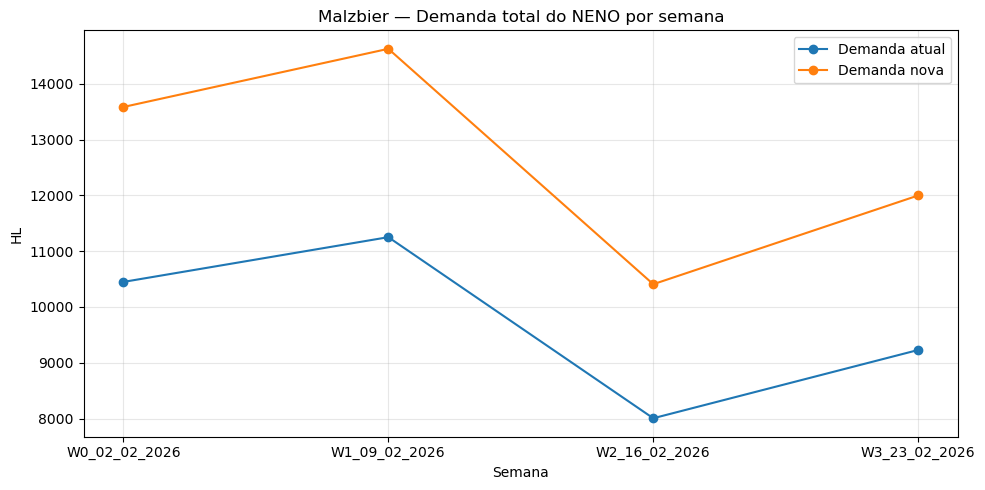

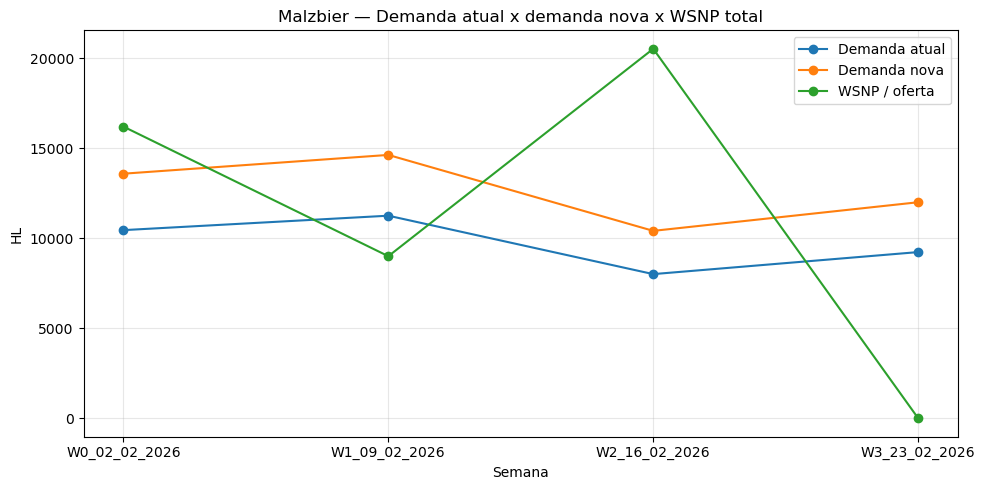

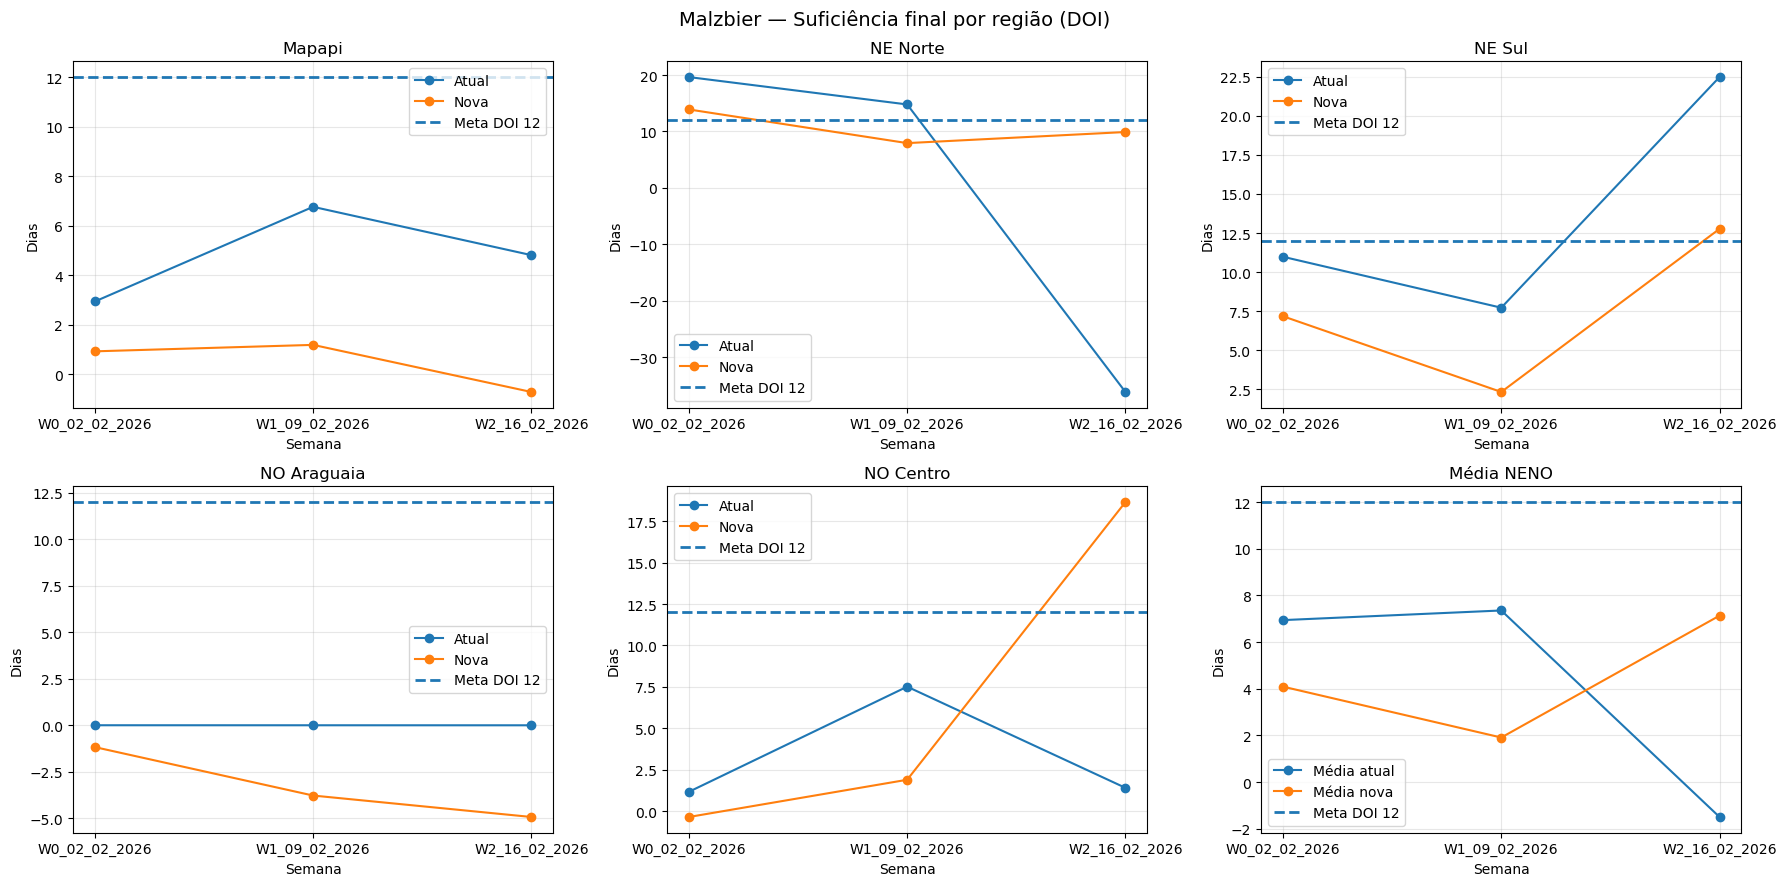

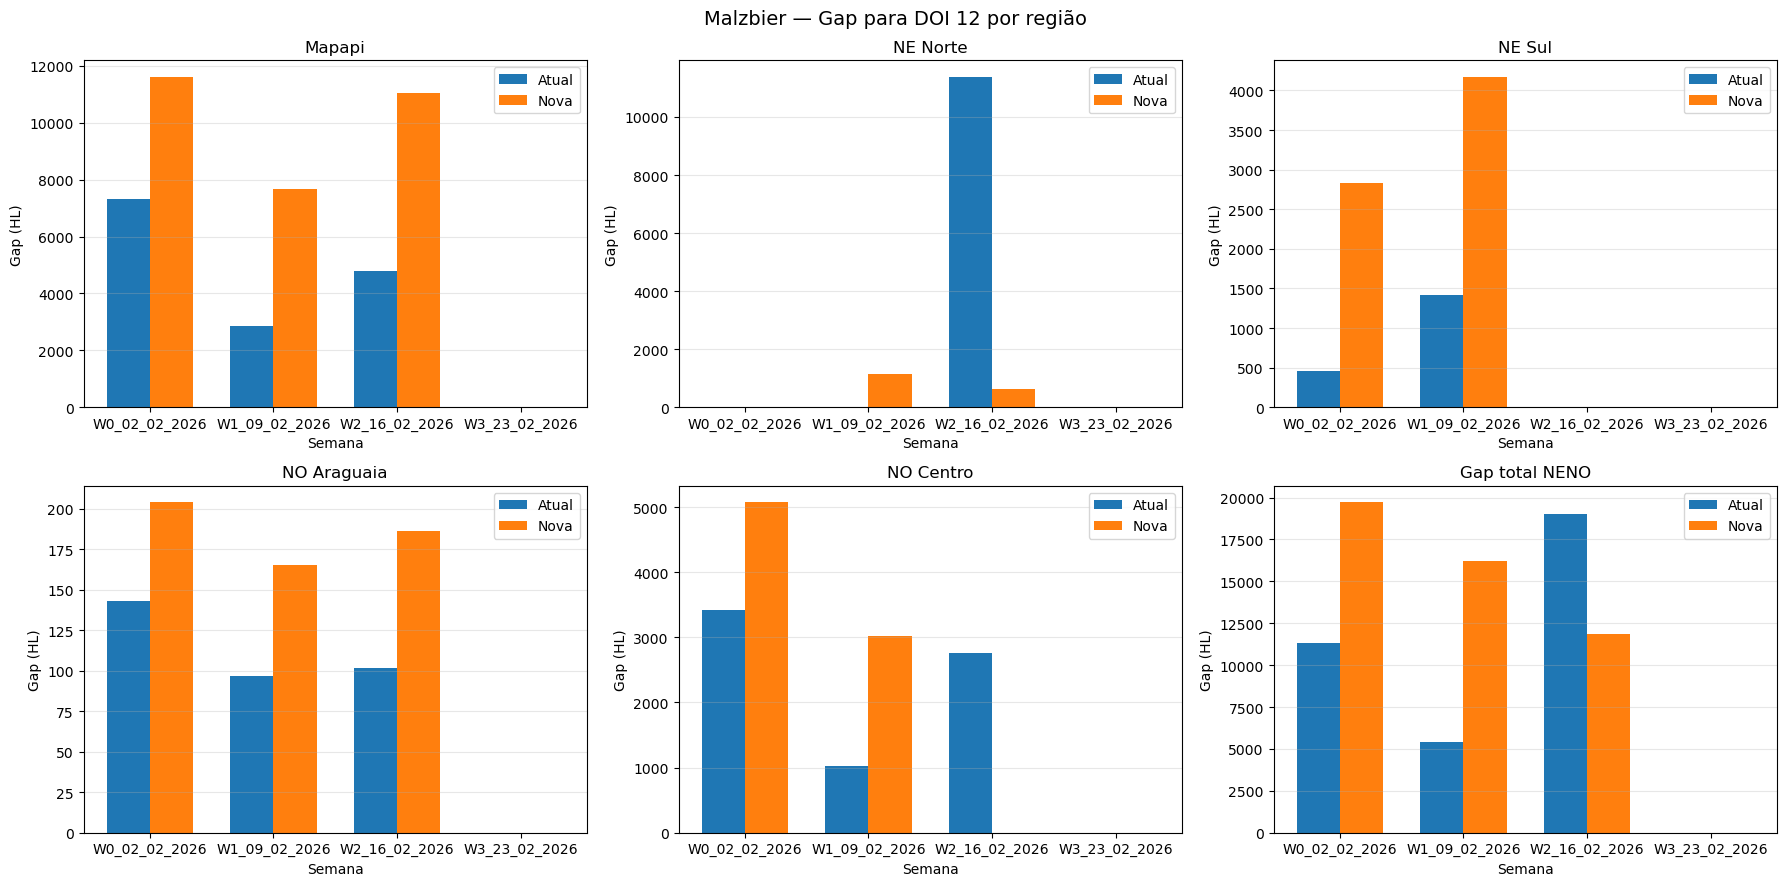

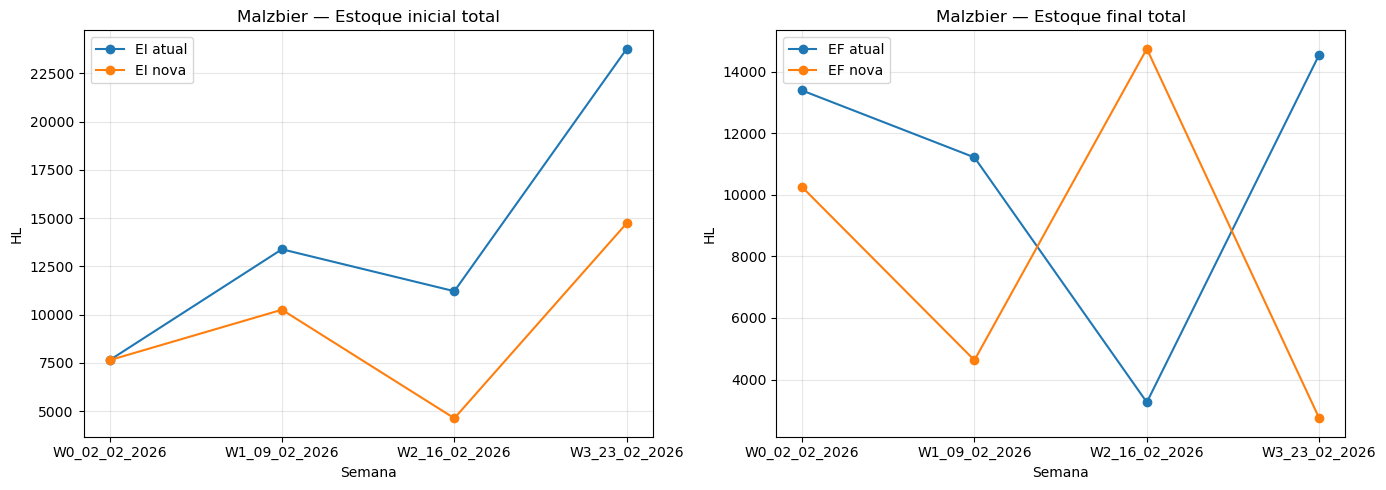

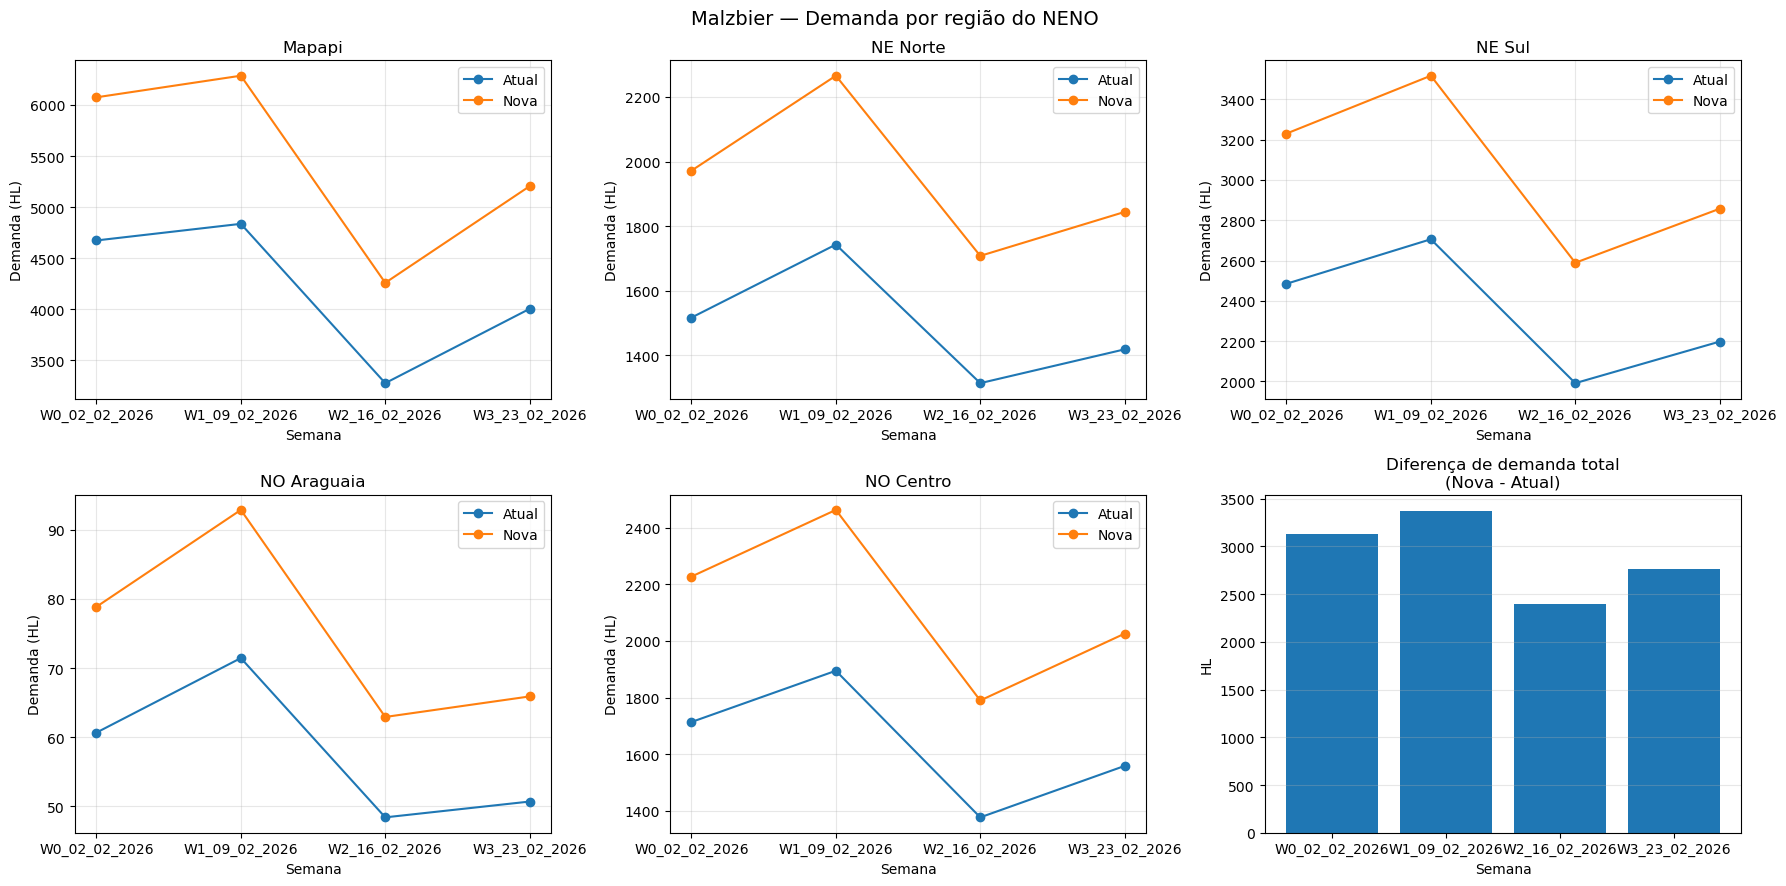

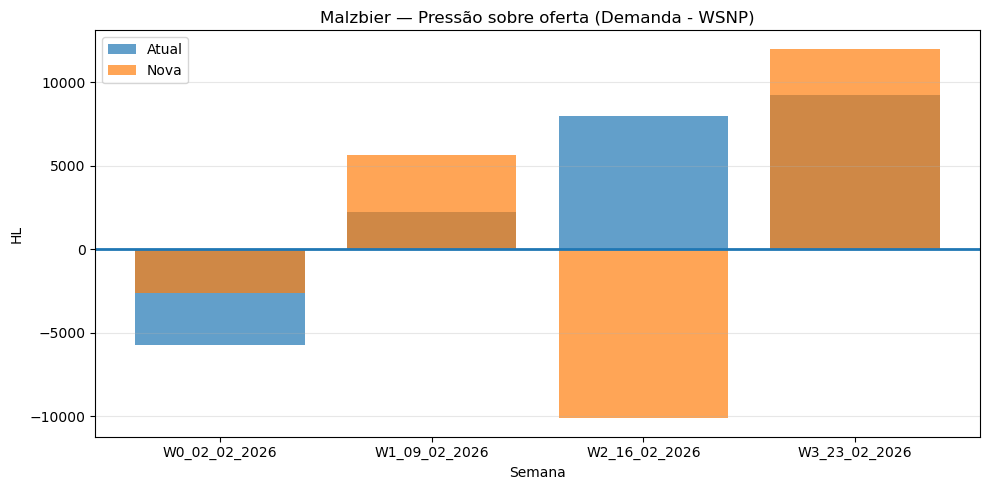

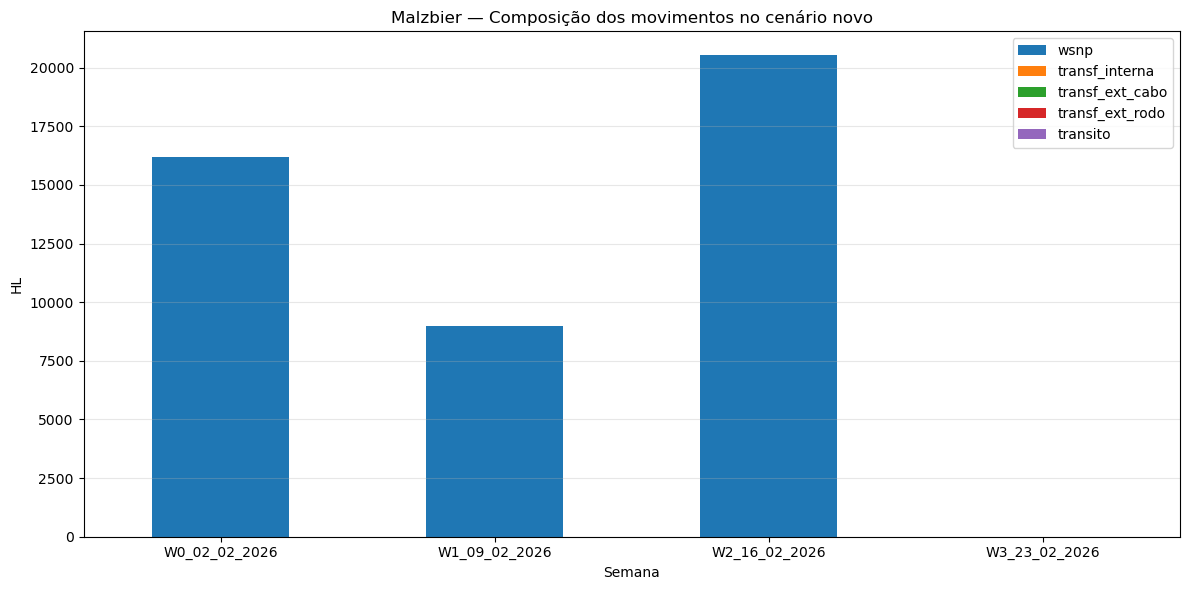

C:\Users\capoz\AppData\Local\Temp\ipykernel_27084\3148296150.py:255: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  nova.pivot_table(


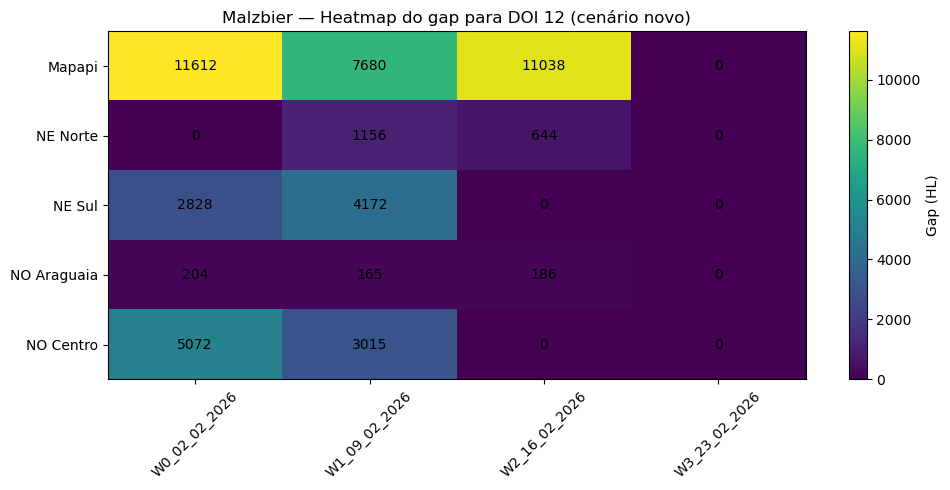

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURAÇÃO
# =========================================================
REGIOES_NENO = ["Mapapi", "NE Norte", "NE Sul", "NO Araguaia", "NO Centro"]
ORDEM_SEMANAS = ["W0_02_02_2026", "W1_09_02_2026", "W2_16_02_2026", "W3_23_02_2026"]

def prepara_base_neno(df):
    base = df.copy()
    base = base[df["geo_reg"].isin(REGIOES_NENO)].copy()
    base["semana"] = pd.Categorical(base["semana"], categories=ORDEM_SEMANAS, ordered=True)
    base = base.sort_values(["geo_reg", "semana"])
    return base

# bases
atual = prepara_base_neno(malzbier_atual)
nova = prepara_base_neno(malzbier_nova)

# agregados totais
resumo_atual = (
    atual.groupby("semana", observed=False)[
        ["demanda_semana", "wsnp", "ei_semana", "ef_semana", "gap_ef_12", "surplus_ef_12", "suf_f_d"]
    ]
    .sum()
    .reindex(ORDEM_SEMANAS)
)

resumo_nova = (
    nova.groupby("semana", observed=False)[
        ["demanda_semana", "wsnp", "ei_semana", "ef_semana", "gap_ef_12", "surplus_ef_12", "suf_f_d"]
    ]
    .sum()
    .reindex(ORDEM_SEMANAS)
)

# para suficiência total agregada, média por região é mais interpretável
suf_media_atual = (
    atual.groupby("semana", observed=False)["suf_f_d"]
    .mean()
    .reindex(ORDEM_SEMANAS)
)

suf_media_nova = (
    nova.groupby("semana", observed=False)["suf_f_d"]
    .mean()
    .reindex(ORDEM_SEMANAS)
)

# =========================================================
# 1) DEMANDA ATUAL x DEMANDA NOVA
# =========================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(resumo_atual.index, resumo_atual["demanda_semana"], marker="o", label="Demanda atual")
ax.plot(resumo_nova.index, resumo_nova["demanda_semana"], marker="o", label="Demanda nova")
ax.set_title("Malzbier — Demanda total do NENO por semana")
ax.set_xlabel("Semana")
ax.set_ylabel("HL")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 2) DEMANDA x WSNP / OFERTA
# =========================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(resumo_atual.index, resumo_atual["demanda_semana"], marker="o", label="Demanda atual")
ax.plot(resumo_nova.index, resumo_nova["demanda_semana"], marker="o", label="Demanda nova")
ax.plot(resumo_nova.index, resumo_nova["wsnp"], marker="o", label="WSNP / oferta")
ax.set_title("Malzbier — Demanda atual x demanda nova x WSNP total")
ax.set_xlabel("Semana")
ax.set_ylabel("HL")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 3) DOI / SUFICIÊNCIA FINAL POR REGIÃO
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle("Malzbier — Suficiência final por região (DOI)", fontsize=14)

for i, regiao in enumerate(REGIOES_NENO):
    ax = axes[i]
    atual_reg = atual[atual["geo_reg"] == regiao]
    nova_reg = nova[nova["geo_reg"] == regiao]

    ax.plot(atual_reg["semana"], atual_reg["suf_f_d"], marker="o", label="Atual")
    ax.plot(nova_reg["semana"], nova_reg["suf_f_d"], marker="o", label="Nova")
    ax.axhline(12, linestyle="--", linewidth=2, label="Meta DOI 12")
    ax.set_title(regiao)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Dias")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[5].plot(suf_media_atual.index, suf_media_atual.values, marker="o", label="Média atual")
axes[5].plot(suf_media_nova.index, suf_media_nova.values, marker="o", label="Média nova")
axes[5].axhline(12, linestyle="--", linewidth=2, label="Meta DOI 12")
axes[5].set_title("Média NENO")
axes[5].set_xlabel("Semana")
axes[5].set_ylabel("Dias")
axes[5].grid(True, alpha=0.3)
axes[5].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 4) GAP PARA DOI 12 POR REGIÃO
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle("Malzbier — Gap para DOI 12 por região", fontsize=14)

for i, regiao in enumerate(REGIOES_NENO):
    ax = axes[i]
    atual_reg = atual[atual["geo_reg"] == regiao]
    nova_reg = nova[nova["geo_reg"] == regiao]

    x = np.arange(len(ORDEM_SEMANAS))
    largura = 0.35

    atual_vals = atual_reg.set_index("semana").reindex(ORDEM_SEMANAS)["gap_ef_12"].fillna(0).values
    nova_vals = nova_reg.set_index("semana").reindex(ORDEM_SEMANAS)["gap_ef_12"].fillna(0).values

    ax.bar(x - largura/2, atual_vals, largura, label="Atual")
    ax.bar(x + largura/2, nova_vals, largura, label="Nova")
    ax.set_title(regiao)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Gap (HL)")
    ax.set_xticks(x)
    ax.set_xticklabels(ORDEM_SEMANAS)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

x = np.arange(len(ORDEM_SEMANAS))
largura = 0.35
axes[5].bar(x - largura/2, resumo_atual["gap_ef_12"].values, largura, label="Atual")
axes[5].bar(x + largura/2, resumo_nova["gap_ef_12"].values, largura, label="Nova")
axes[5].set_title("Gap total NENO")
axes[5].set_xlabel("Semana")
axes[5].set_ylabel("Gap (HL)")
axes[5].set_xticks(x)
axes[5].set_xticklabels(ORDEM_SEMANAS)
axes[5].grid(True, axis="y", alpha=0.3)
axes[5].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 5) ESTOQUE INICIAL x ESTOQUE FINAL
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resumo_atual.index, resumo_atual["ei_semana"], marker="o", label="EI atual")
axes[0].plot(resumo_nova.index, resumo_nova["ei_semana"], marker="o", label="EI nova")
axes[0].set_title("Malzbier — Estoque inicial total")
axes[0].set_xlabel("Semana")
axes[0].set_ylabel("HL")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(resumo_atual.index, resumo_atual["ef_semana"], marker="o", label="EF atual")
axes[1].plot(resumo_nova.index, resumo_nova["ef_semana"], marker="o", label="EF nova")
axes[1].set_title("Malzbier — Estoque final total")
axes[1].set_xlabel("Semana")
axes[1].set_ylabel("HL")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 6) DEMANDA POR REGIÃO
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle("Malzbier — Demanda por região do NENO", fontsize=14)

for i, regiao in enumerate(REGIOES_NENO):
    ax = axes[i]
    atual_reg = atual[atual["geo_reg"] == regiao]
    nova_reg = nova[nova["geo_reg"] == regiao]

    ax.plot(atual_reg["semana"], atual_reg["demanda_semana"], marker="o", label="Atual")
    ax.plot(nova_reg["semana"], nova_reg["demanda_semana"], marker="o", label="Nova")
    ax.set_title(regiao)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Demanda (HL)")
    ax.grid(True, alpha=0.3)
    ax.legend()

dif_demanda = (resumo_nova["demanda_semana"] - resumo_atual["demanda_semana"]).fillna(0)
axes[5].bar(dif_demanda.index.astype(str), dif_demanda.values)
axes[5].set_title("Diferença de demanda total\n(Nova - Atual)")
axes[5].set_xlabel("Semana")
axes[5].set_ylabel("HL")
axes[5].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# 7) PRESSÃO SOBRE A OFERTA
# =========================================================
pressao_nova = (resumo_nova["demanda_semana"] - resumo_nova["wsnp"]).fillna(0)
pressao_atual = (resumo_atual["demanda_semana"] - resumo_atual["wsnp"]).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pressao_atual.index.astype(str), pressao_atual.values, alpha=0.7, label="Atual")
ax.bar(pressao_nova.index.astype(str), pressao_nova.values, alpha=0.7, label="Nova")
ax.axhline(0, linewidth=2)
ax.set_title("Malzbier — Pressão sobre oferta (Demanda - WSNP)")
ax.set_xlabel("Semana")
ax.set_ylabel("HL")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 8) COMPOSIÇÃO DOS MOVIMENTOS - CENÁRIO NOVO
# =========================================================
comp_nova = (
    nova.groupby("semana", observed=False)[
        ["wsnp", "transf_interna", "transf_ext_cabo", "transf_ext_rodo", "transito"]
    ]
    .sum()
    .reindex(ORDEM_SEMANAS)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 6))
comp_nova.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Malzbier — Composição dos movimentos no cenário novo")
ax.set_xlabel("Semana")
ax.set_ylabel("HL")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================================================
# 9) HEATMAP SIMPLES DO GAP NO CENÁRIO NOVO
# =========================================================
pivot_gap = (
    nova.pivot_table(
        index="geo_reg",
        columns="semana",
        values="gap_ef_12",
        aggfunc="sum"
    )
    .reindex(index=REGIOES_NENO, columns=ORDEM_SEMANAS)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot_gap.values, aspect="auto")

ax.set_title("Malzbier — Heatmap do gap para DOI 12 (cenário novo)")
ax.set_xticks(range(len(pivot_gap.columns)))
ax.set_xticklabels(pivot_gap.columns, rotation=45)
ax.set_yticks(range(len(pivot_gap.index)))
ax.set_yticklabels(pivot_gap.index)

for i in range(pivot_gap.shape[0]):
    for j in range(pivot_gap.shape[1]):
        ax.text(j, i, f"{pivot_gap.iloc[i, j]:.0f}", ha="center", va="center")

plt.colorbar(im, ax=ax, label="Gap (HL)")
plt.tight_layout()
plt.show()

## 4) Análise comparativa de fevereiro e março para todas as cervejas

Neste bloco, foram construídos gráficos comparativos para avaliar o comportamento das quatro cervejas (**Patagonia, Goose, Malzbier e Colorado**) no NENO ao longo de **fevereiro e março**, considerando tanto o **cenário atual** quanto o **cenário novo**.

### O que foi feito

- Foram definidas:
  - as regiões do NENO consideradas na análise
  - a ordem das semanas de fevereiro e março
  - rótulos simplificados do eixo x (`W0` a `W7`) para melhorar a leitura dos gráficos

- Foi criado um dicionário com os pares de bases de cada cerveja:
  - cenário atual com março
  - cenário novo com março

- Também foi criado um dicionário com a **capacidade produtiva máxima semanal** de cada cerveja, com base nas plantas que podem produzi-las:
  - **Patagonia**: somente CE
  - **Goose**: somente PE
  - **Malzbier**: CE + PE
  - **Colorado**: CE + PE
  - além da capacidade máxima conjunta total

- Foi utilizada uma função auxiliar para:
  - filtrar apenas as regiões do NENO
  - ordenar corretamente as semanas
  - deixar as bases prontas para agregação e plotagem

### Gráficos gerados

**1. Demanda total por cerveja e semana**
- Compara, para cada cerveja, a demanda total no NENO entre cenário atual e cenário novo.

**2. Pressão sobre oferta**
- Mede a diferença entre `demanda_semana` e `wsnp`.
- Esse gráfico ajuda a identificar em quais semanas a demanda supera a oferta programada.

**3. DOI médio por cerveja**
- Mostra a suficiência final média em dias ao longo das semanas.
- Inclui uma linha de referência na meta de **DOI 12**.

**4. Gap total para DOI 12**
- Mostra, por cerveja, o volume faltante total para atingir a meta de cobertura mínima.

**5. Capacidade produtiva máxima x demanda total das quatro cervejas**
- Compara a demanda agregada de todas as cervejas com a capacidade máxima produtiva total disponível.
- Esse gráfico ajuda a avaliar se a limitação é apenas logística ou se existe risco estrutural de produção.

**6. Capacidade produtiva máxima x demanda por cerveja**
- Faz a mesma comparação individualmente para cada cerveja.
- Permite verificar se a demanda semanal se aproxima ou ultrapassa a capacidade máxima disponível para aquele SKU.

### Resultado

Ao final do bloco, foram geradas visualizações que permitem analisar, para cada cerveja e também de forma consolidada:

- a evolução da demanda em fevereiro e março
- o impacto do cenário novo sobre a oferta
- a manutenção ou não do DOI 12
- o aumento de gaps de cobertura
- a proximidade entre demanda e capacidade produtiva máxima

Esses gráficos ajudam a entender se o problema é apenas de redistribuição e estoque ou se também existe restrição produtiva relevante para sustentar o crescimento de demanda.

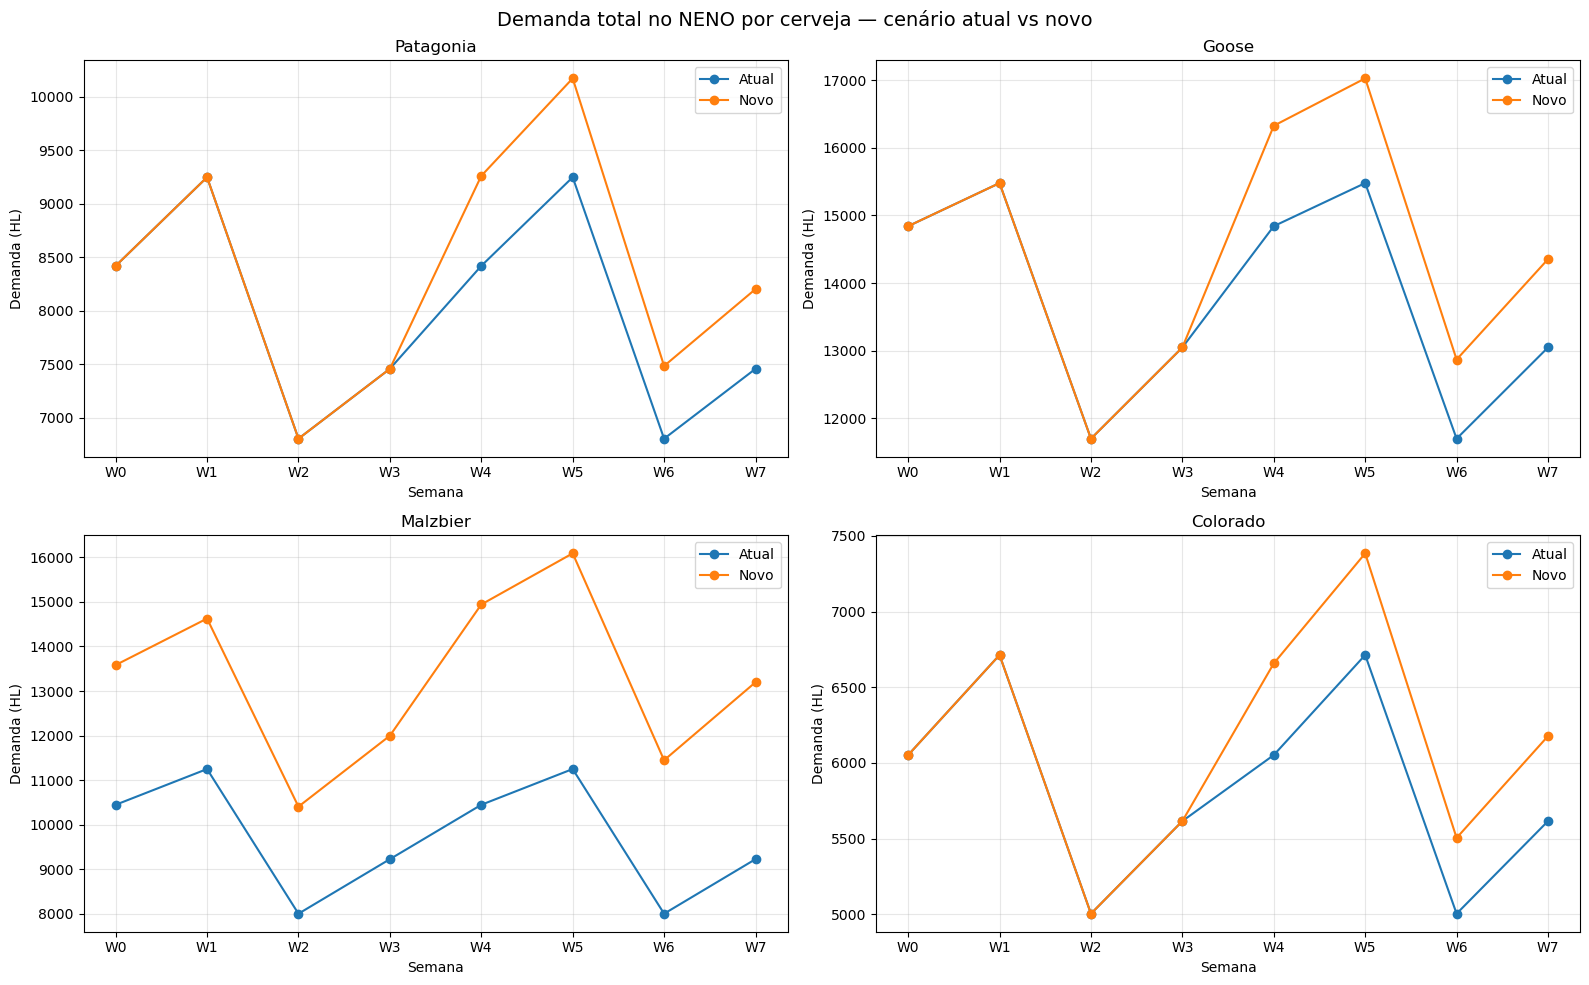

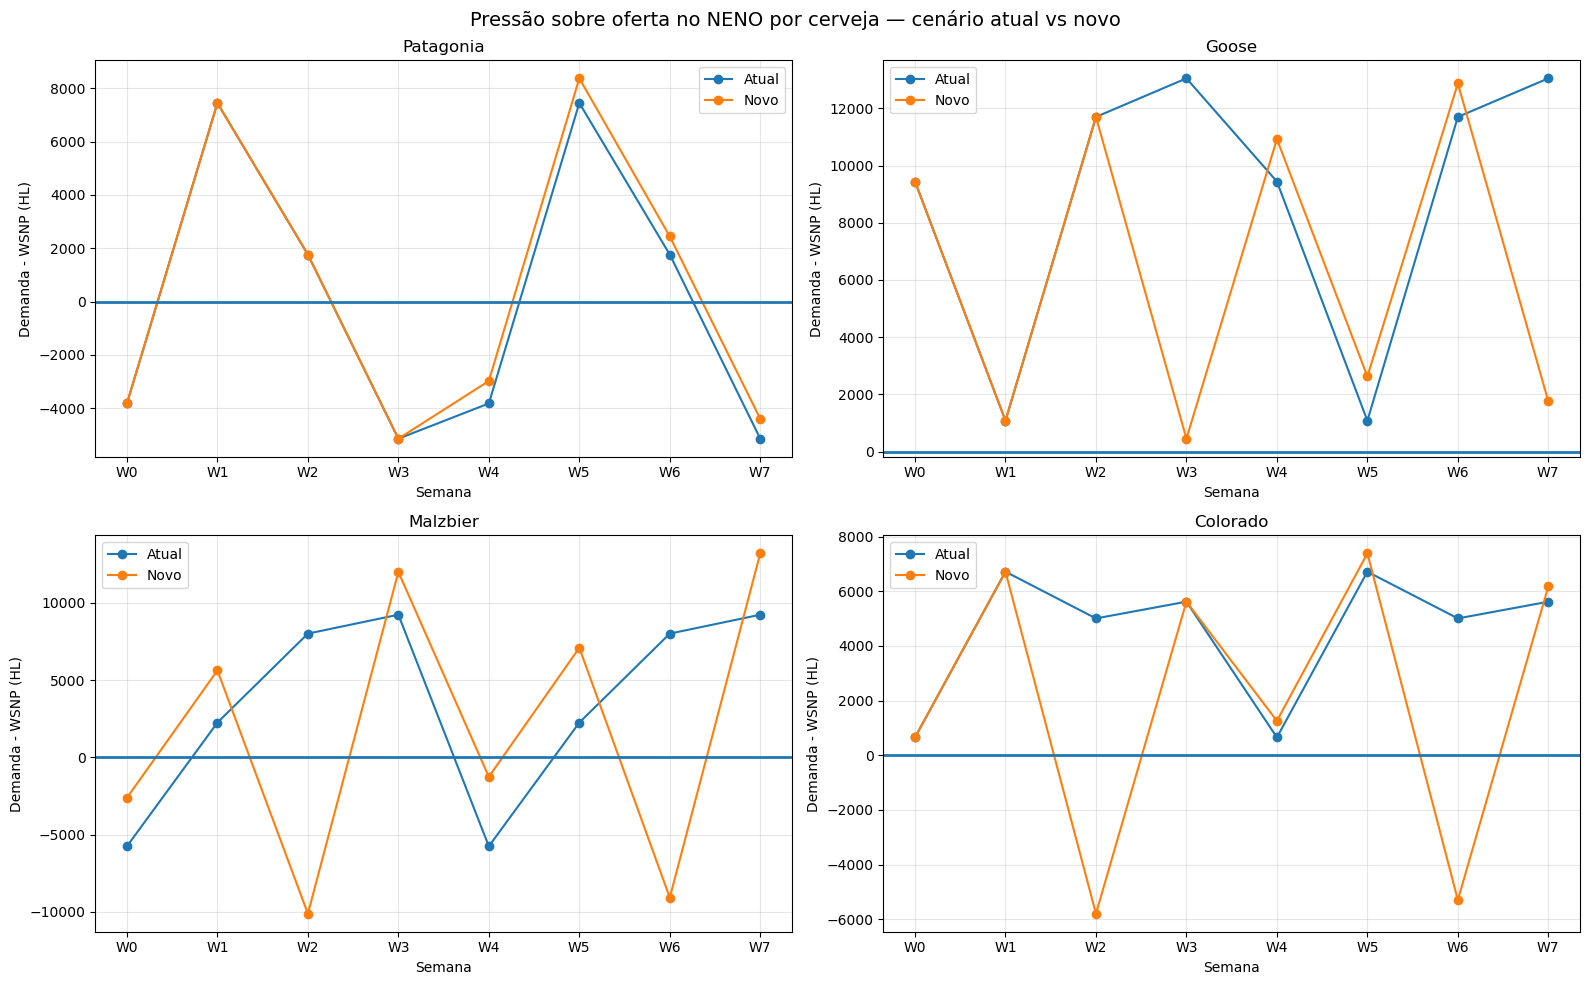

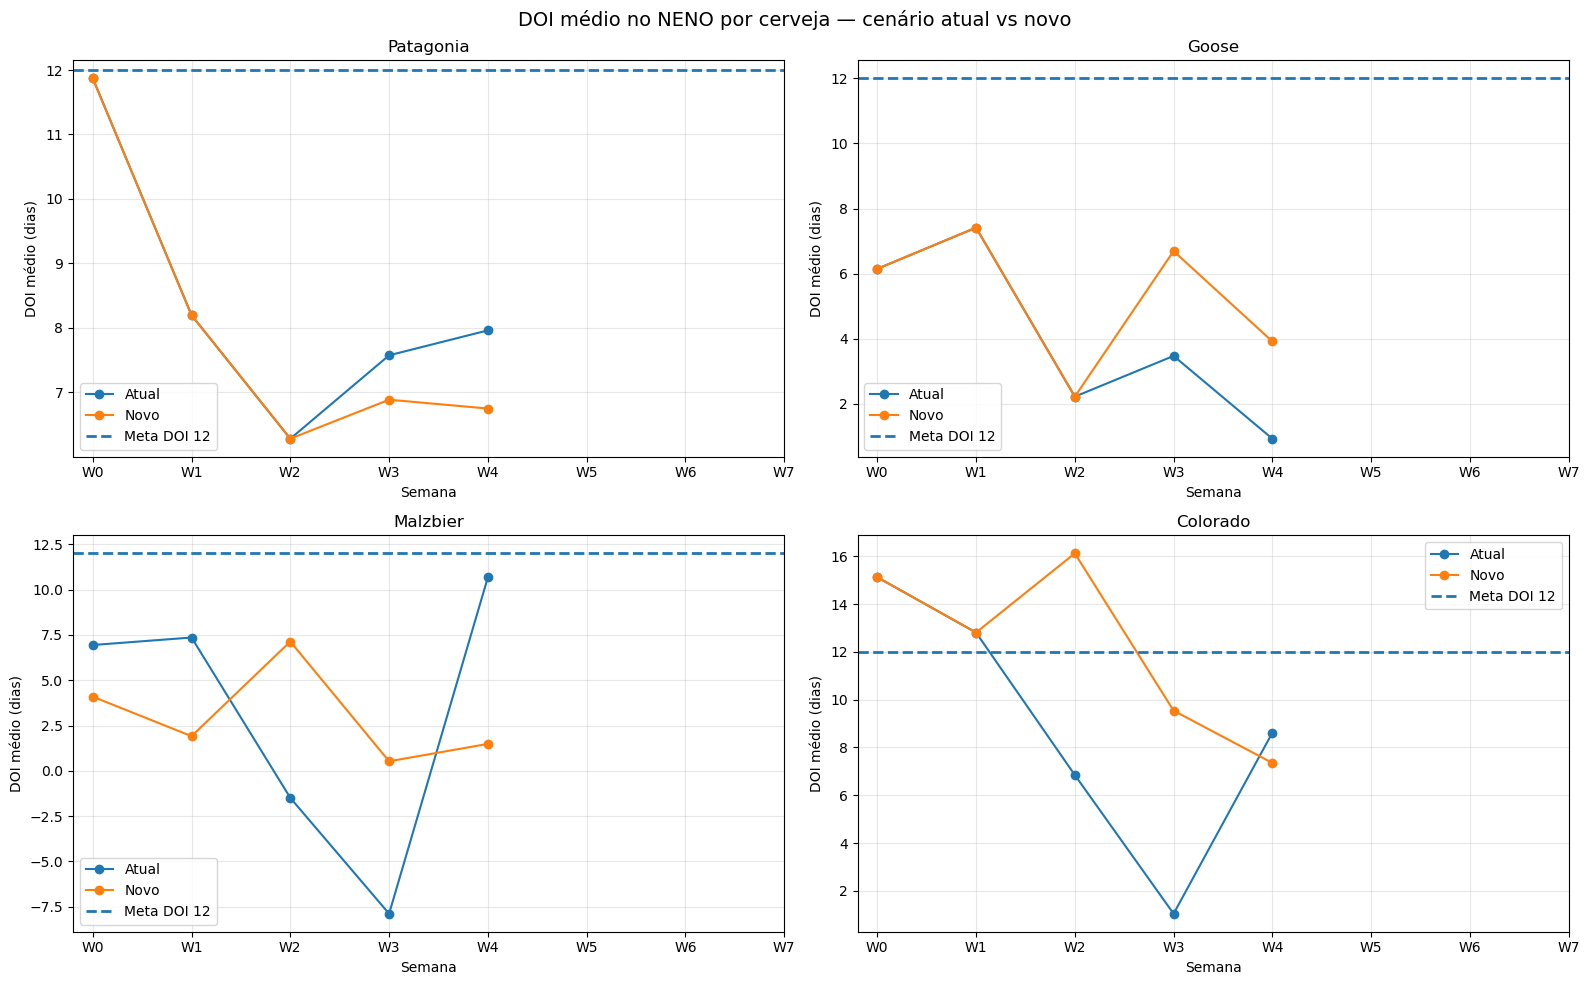

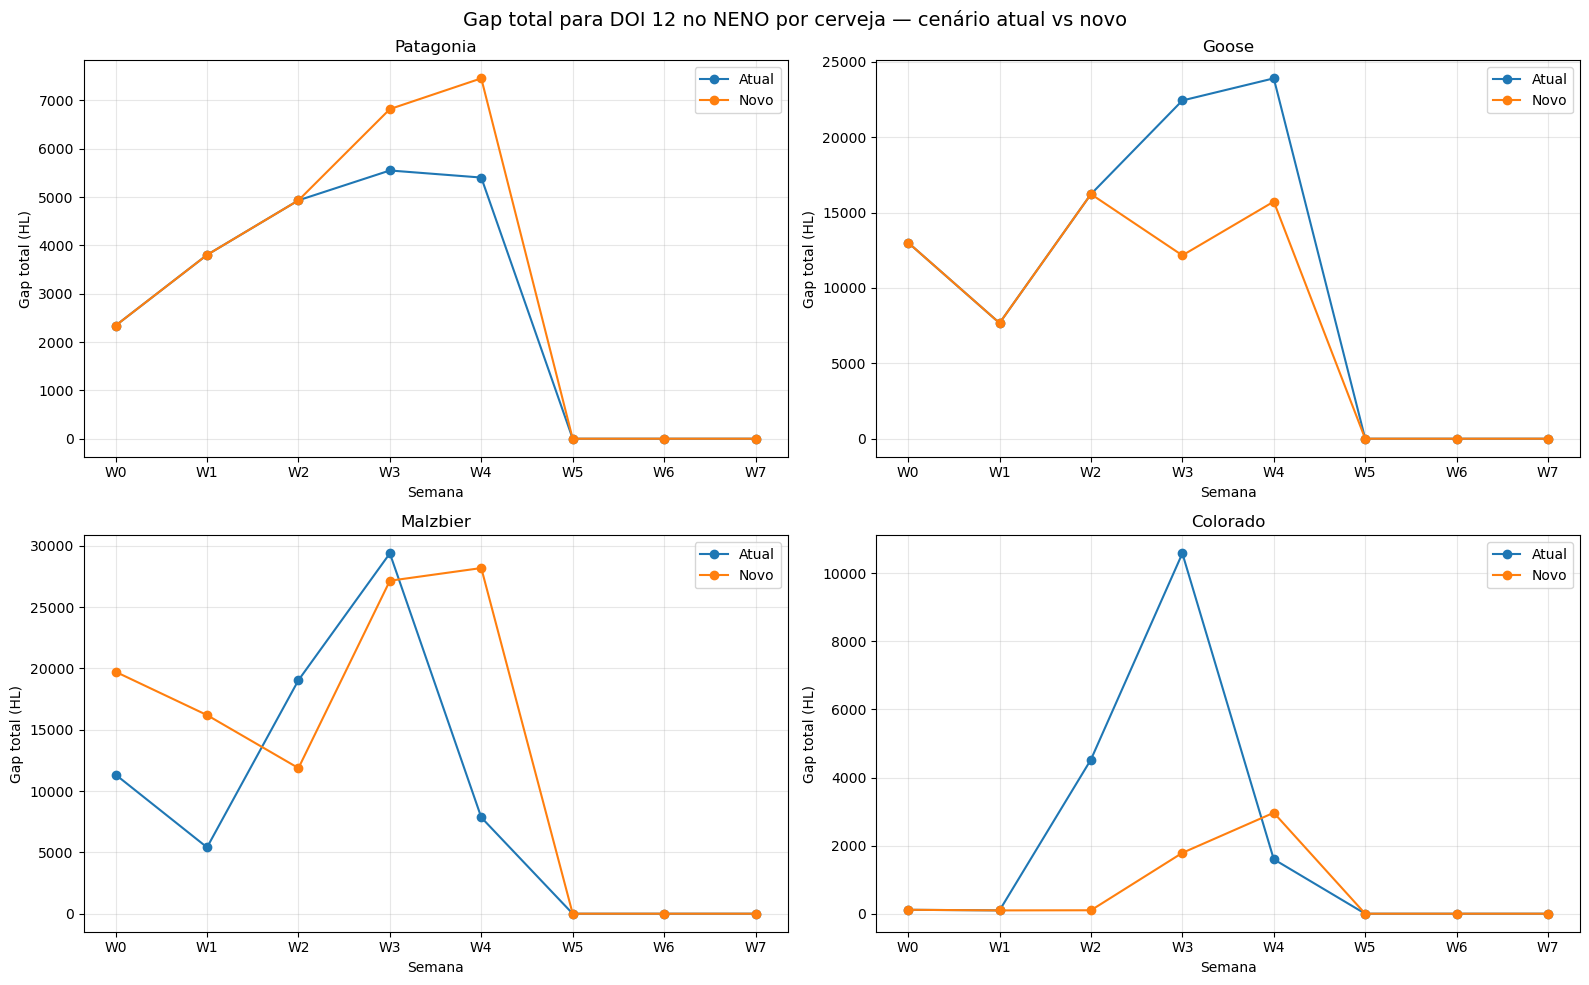

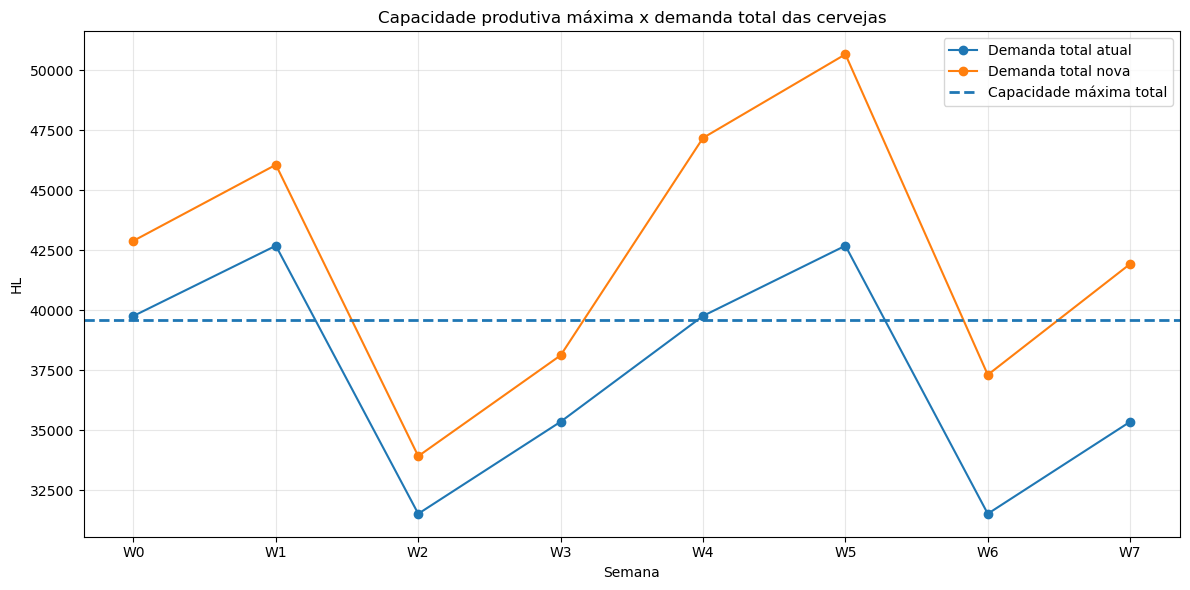

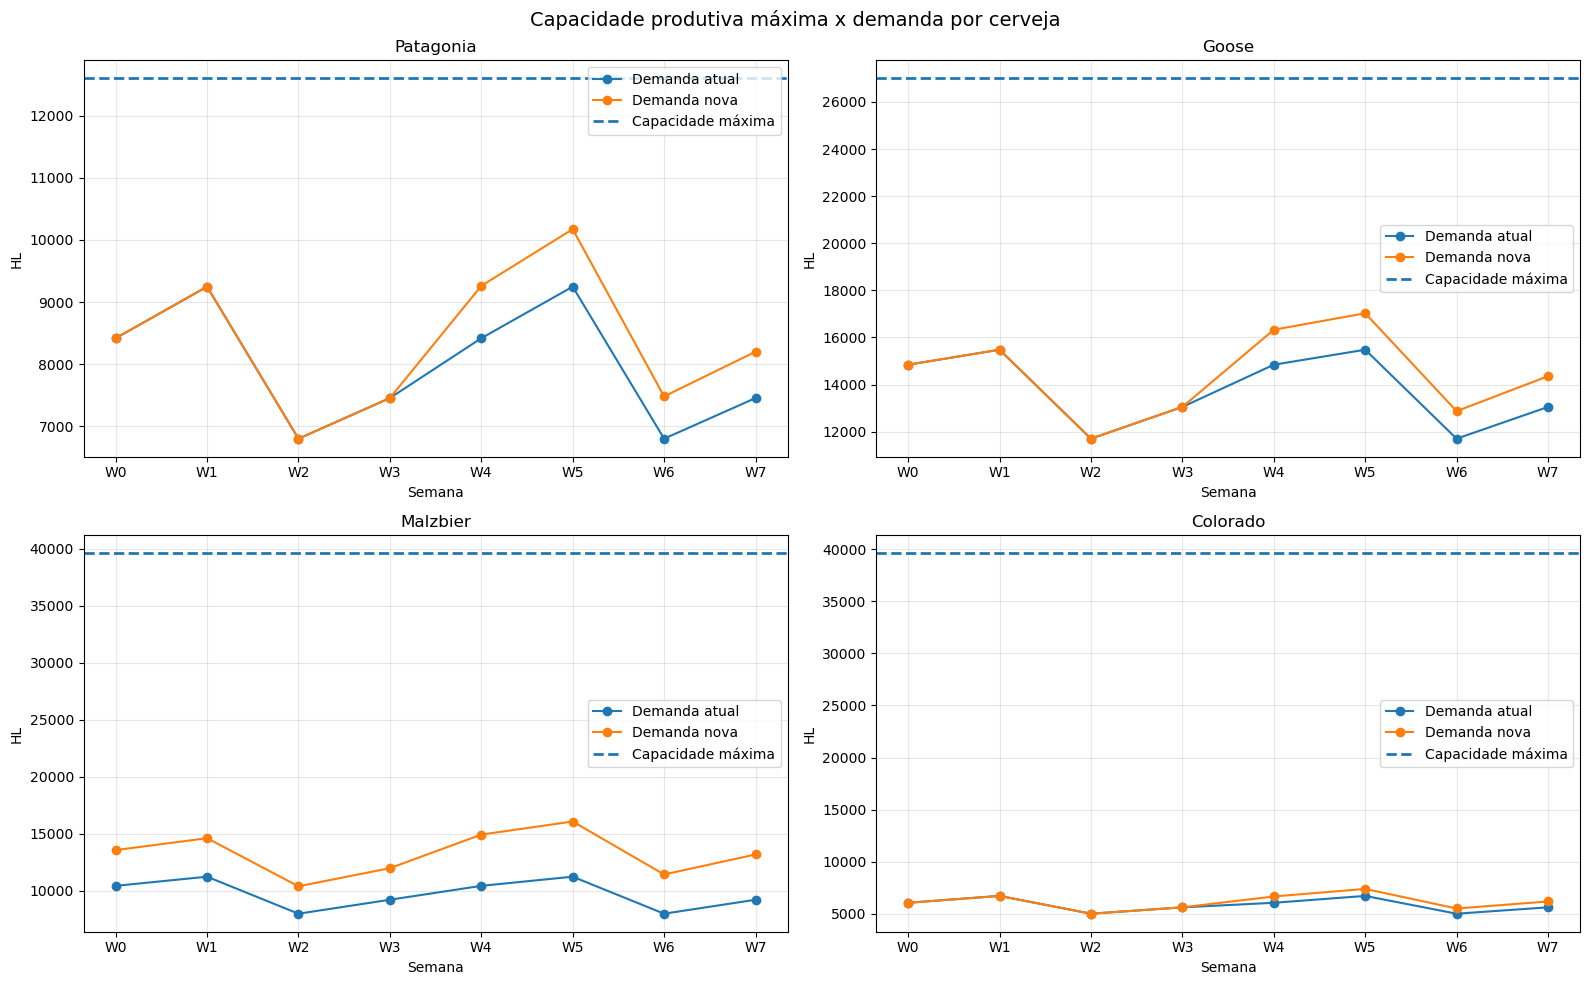

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURAÇÃO
# =========================================================
REGIOES_NENO = ["Mapapi", "NE Norte", "NE Sul", "NO Araguaia", "NO Centro"]

ORDEM_SEMANAS = [
    "W0_02_02_2026",
    "W1_09_02_2026",
    "W2_16_02_2026",
    "W3_23_02_2026",
    "W4_02_03_2026",
    "W5_09_03_2026",
    "W6_16_03_2026",
    "W7_23_03_2026"
]

LABELS_SEMANAS = ["W0", "W1", "W2", "W3", "W4", "W5", "W6", "W7"]
X = np.arange(len(ORDEM_SEMANAS))

PARES_CERVEJAS = {
    "Patagonia": (patagonia_atual_mar, patagonia_nova_mar),
    "Goose": (goose_atual_mar, goose_nova_mar),
    "Malzbier": (malzbier_atual_mar, malzbier_nova_mar),
    "Colorado": (colorado_atual_mar, colorado_nova_mar),
}

# capacidade máxima semanal por cerveja (hl/semana)
CAPACIDADE_MAXIMA = {
    "Patagonia": 12600,   # somente CE
    "Goose": 27000,       # somente PE
    "Malzbier": 39600,    # CE + PE
    "Colorado": 39600,    # CE + PE
    "Total": 39600        # capacidade conjunta CE + PE
}

def prepara_base_neno(df):
    base = df.copy()
    base = base[base["geo_reg"].isin(REGIOES_NENO)].copy()
    base["semana"] = pd.Categorical(base["semana"], categories=ORDEM_SEMANAS, ordered=True)
    base = base.sort_values(["geo_reg", "semana"])
    return base

# =========================================================
# 1) DEMANDA TOTAL POR CERVEJA E SEMANA
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("Demanda total no NENO por cerveja — cenário atual vs novo", fontsize=14)

for i, (nome, (df_atual, df_nova)) in enumerate(PARES_CERVEJAS.items()):
    ax = axes[i]

    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    resumo_atual = (
        atual.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )
    resumo_nova = (
        nova.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )

    ax.plot(X, resumo_atual.values, marker="o", label="Atual")
    ax.plot(X, resumo_nova.values, marker="o", label="Novo")
    ax.set_title(nome)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Demanda (HL)")
    ax.set_xticks(X)
    ax.set_xticklabels(LABELS_SEMANAS)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 2) PRESSÃO SOBRE OFERTA (DEMANDA - WSNP)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("Pressão sobre oferta no NENO por cerveja — cenário atual vs novo", fontsize=14)

for i, (nome, (df_atual, df_nova)) in enumerate(PARES_CERVEJAS.items()):
    ax = axes[i]

    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    resumo_atual = (
        atual.groupby("semana", observed=False)[["demanda_semana", "wsnp"]]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )
    resumo_nova = (
        nova.groupby("semana", observed=False)[["demanda_semana", "wsnp"]]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )

    pressao_atual = resumo_atual["demanda_semana"] - resumo_atual["wsnp"]
    pressao_nova = resumo_nova["demanda_semana"] - resumo_nova["wsnp"]

    ax.plot(X, pressao_atual.values, marker="o", label="Atual")
    ax.plot(X, pressao_nova.values, marker="o", label="Novo")
    ax.axhline(0, linewidth=2)
    ax.set_title(nome)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Demanda - WSNP (HL)")
    ax.set_xticks(X)
    ax.set_xticklabels(LABELS_SEMANAS)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 3) DOI MÉDIO POR CERVEJA
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("DOI médio no NENO por cerveja — cenário atual vs novo", fontsize=14)

for i, (nome, (df_atual, df_nova)) in enumerate(PARES_CERVEJAS.items()):
    ax = axes[i]

    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    doi_atual = (
        atual.groupby("semana", observed=False)["suf_f_d"]
        .mean()
        .reindex(ORDEM_SEMANAS)
    )
    doi_nova = (
        nova.groupby("semana", observed=False)["suf_f_d"]
        .mean()
        .reindex(ORDEM_SEMANAS)
    )

    ax.plot(X, doi_atual.values, marker="o", label="Atual")
    ax.plot(X, doi_nova.values, marker="o", label="Novo")
    ax.axhline(12, linestyle="--", linewidth=2, label="Meta DOI 12")
    ax.set_title(nome)
    ax.set_xlabel("Semana")
    ax.set_ylabel("DOI médio (dias)")
    ax.set_xticks(X)
    ax.set_xticklabels(LABELS_SEMANAS)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 4) GAP TOTAL PARA DOI 12
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("Gap total para DOI 12 no NENO por cerveja — cenário atual vs novo", fontsize=14)

for i, (nome, (df_atual, df_nova)) in enumerate(PARES_CERVEJAS.items()):
    ax = axes[i]

    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    gap_atual = (
        atual.groupby("semana", observed=False)["gap_ef_12"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )
    gap_nova = (
        nova.groupby("semana", observed=False)["gap_ef_12"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )

    ax.plot(X, gap_atual.values, marker="o", label="Atual")
    ax.plot(X, gap_nova.values, marker="o", label="Novo")
    ax.set_title(nome)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Gap total (HL)")
    ax.set_xticks(X)
    ax.set_xticklabels(LABELS_SEMANAS)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 5) CAPACIDADE PRODUTIVA MÁXIMA x DEMANDA TOTAL DAS 4 CERVEJAS
# =========================================================
fig, ax = plt.subplots(figsize=(12, 6))

demanda_total_atual = pd.Series(0.0, index=ORDEM_SEMANAS)
demanda_total_nova = pd.Series(0.0, index=ORDEM_SEMANAS)

for nome, (df_atual, df_nova) in PARES_CERVEJAS.items():
    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    demanda_total_atual += (
        atual.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
        .fillna(0)
    )

    demanda_total_nova += (
        nova.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
        .fillna(0)
    )

ax.plot(X, demanda_total_atual.values, marker="o", label="Demanda total atual")
ax.plot(X, demanda_total_nova.values, marker="o", label="Demanda total nova")
ax.axhline(CAPACIDADE_MAXIMA["Total"], linestyle="--", linewidth=2, label="Capacidade máxima total")

ax.set_title("Capacidade produtiva máxima x demanda total das cervejas")
ax.set_xlabel("Semana")
ax.set_ylabel("HL")
ax.set_xticks(X)
ax.set_xticklabels(LABELS_SEMANAS)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 6) CAPACIDADE PRODUTIVA MÁXIMA x DEMANDA — UMA FIGURA POR CERVEJA
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("Capacidade produtiva máxima x demanda por cerveja", fontsize=14)

for i, (nome, (df_atual, df_nova)) in enumerate(PARES_CERVEJAS.items()):
    ax = axes[i]

    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    demanda_atual = (
        atual.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )

    demanda_nova = (
        nova.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )

    capacidade = CAPACIDADE_MAXIMA[nome]

    ax.plot(X, demanda_atual.values, marker="o", label="Demanda atual")
    ax.plot(X, demanda_nova.values, marker="o", label="Demanda nova")
    ax.axhline(capacidade, linestyle="--", linewidth=2, label="Capacidade máxima")

    ax.set_title(nome)
    ax.set_xlabel("Semana")
    ax.set_ylabel("HL")
    ax.set_xticks(X)
    ax.set_xticklabels(LABELS_SEMANAS)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [4]:
# =========================
# 1) leitura
# =========================
saopaulo_raw = pd.read_excel(
    arquivo,
    sheet_name="SãoPaulo",   # ajuste se o nome da aba estiver diferente
    engine="pyxlsb"
)

# =========================
# 2) limpeza inicial
# =========================
saopaulo_raw = saopaulo_raw.loc[
    :, ~pd.Index(saopaulo_raw.columns).astype(str).str.contains("^Unnamed", na=False)
].copy()

saopaulo_raw.columns = [str(c).strip() for c in saopaulo_raw.columns]

# valida colunas fixas
colunas_fixas_necessarias = ["SKO", "GEO/REG"]
faltantes_fixas = [c for c in colunas_fixas_necessarias if c not in saopaulo_raw.columns]
if faltantes_fixas:
    raise ValueError(f"Faltam colunas fixas esperadas: {faltantes_fixas}")

cols = saopaulo_raw.columns.tolist()

# =========================
# 3) semana 0
# =========================
bloco_w0_excel = [
    "Demanda",
    "WSNP",
    "EI Semana",
    "Suf.ini(d)",
    "Transf. Interna",
    "Transf. Ext (Cabo)",
    "Transf. Ext (Rodo)",
    "Trânsito",
    "EF Semana",
    "Suf. f (d)"
]

faltantes_w0 = [c for c in bloco_w0_excel if c not in cols]
if faltantes_w0:
    raise ValueError(f"Faltam colunas esperadas da semana 0 em SP: {faltantes_w0}")

sem0 = saopaulo_raw[["SKO", "GEO/REG"] + bloco_w0_excel].copy()
sem0.columns = [
    "sku",
    "geo_reg",
    "demanda_semana",
    "wsnp",
    "ei_semana",
    "suf_ini_d",
    "transf_interna",
    "transf_ext_cabo",
    "transf_ext_rodo",
    "transito",
    "ef_semana",
    "suf_f_d"
]
sem0["semana_idx"] = 0

dfs_semanais = [sem0]

# =========================
# 4) auxiliares
# =========================
def pega_coluna(df, candidatos, default=0.0):
    for c in candidatos:
        if c in df.columns:
            return df[c]
    return pd.Series([default] * len(df), index=df.index)

# =========================
# 5) semanas seguintes
# =========================
idxs_demanda_n = [
    i for i, c in enumerate(cols)
    if str(c).startswith("Demanda.")
]

for idx in idxs_demanda_n:
    col_dem = cols[idx]
    sufixo = col_dem.split(".", 1)[1]   # ex.: "1", "2", "3"

    df_sem = pd.DataFrame(index=saopaulo_raw.index)
    df_sem["sku"] = saopaulo_raw["SKO"]
    df_sem["geo_reg"] = saopaulo_raw["GEO/REG"]

    df_sem["demanda_semana"] = pega_coluna(
        saopaulo_raw,
        [f"Demanda.{sufixo}"],
        default=np.nan
    )

    # aceita WSNP.n ou Malha.n caso a planilha troque o nome
    df_sem["wsnp"] = pega_coluna(
        saopaulo_raw,
        [f"WSNP.{sufixo}", f"Malha.{sufixo}"],
        default=0.0
    )

    df_sem["ei_semana"] = np.nan
    df_sem["suf_ini_d"] = np.nan

    df_sem["transf_interna"] = pega_coluna(
        saopaulo_raw,
        [f"Transf. Interna.{sufixo}"],
        default=0.0
    )

    df_sem["transf_ext_cabo"] = pega_coluna(
        saopaulo_raw,
        [f"Transf. Ext (Cabo).{sufixo}"],
        default=0.0
    )

    df_sem["transf_ext_rodo"] = pega_coluna(
        saopaulo_raw,
        [f"Transf. Ext (Rodo).{sufixo}"],
        default=0.0
    )

    df_sem["transito"] = pega_coluna(
        saopaulo_raw,
        [f"Trânsito.{sufixo}"],
        default=0.0
    )

    df_sem["ef_semana"] = pega_coluna(
        saopaulo_raw,
        [f"EF Semana.{sufixo}"],
        default=np.nan
    )

    df_sem["suf_f_d"] = pega_coluna(
        saopaulo_raw,
        [f"Suf. f (d).{sufixo}"],
        default=np.nan
    )

    df_sem["semana_idx"] = int(sufixo)

    dfs_semanais.append(df_sem)

# concatena em formato longo
saopaulo_fev = pd.concat(dfs_semanais, ignore_index=True)

# =========================
# 6) ordena e reconstrói EI
# =========================
saopaulo_fev = saopaulo_fev.sort_values(["sku", "semana_idx"]).reset_index(drop=True)

mask_semana_maior_0 = saopaulo_fev["semana_idx"] > 0
saopaulo_fev.loc[mask_semana_maior_0, "ei_semana"] = (
    saopaulo_fev.groupby("sku")["ef_semana"].shift(1)
)

saopaulo_fev["suf_ini_d"] = np.where(
    saopaulo_fev["demanda_semana"].notna() & (saopaulo_fev["demanda_semana"] != 0),
    saopaulo_fev["ei_semana"] / (saopaulo_fev["demanda_semana"] / 6),
    np.nan
)

# =========================
# 7) demanda da próxima semana
# =========================
saopaulo_fev["demanda_prox_semana"] = (
    saopaulo_fev.groupby("sku")["demanda_semana"].shift(-1)
)

# =========================
# 8) nomes das semanas
# =========================
mapa_semanas = {
    0: "W0_02_02_2026",
    1: "W1_09_02_2026",
    2: "W2_16_02_2026",
    3: "W3_23_02_2026"
}

saopaulo_fev["semana"] = saopaulo_fev["semana_idx"].map(mapa_semanas)

# padroniza SKUs para casar com os outros dfs
mapa_sku_sp = {
    "GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12": "GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12",
    "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4": "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4",
    "COLORADO LAGER LN 355ML CX C/12": "COLORADO LAGER LN 355ML CX C/12"
}
saopaulo_fev["sku"] = saopaulo_fev["sku"].replace(mapa_sku_sp)

# =========================
# 9) variáveis derivadas
# =========================
saopaulo_fev["ajuste_cabo"] = saopaulo_fev["transf_ext_cabo"].where(
    saopaulo_fev["transf_ext_cabo"] < 0, 0
)

saopaulo_fev["ef_semana"] = (
    saopaulo_fev["ei_semana"]
    + saopaulo_fev["wsnp"]
    - saopaulo_fev["demanda_semana"]
    + saopaulo_fev["transf_interna"]
    + saopaulo_fev["transf_ext_rodo"]
    + saopaulo_fev["transito"]
    + saopaulo_fev["ajuste_cabo"]
)

saopaulo_fev["suf_f_d"] = np.where(
    saopaulo_fev["demanda_prox_semana"].notna() & (saopaulo_fev["demanda_prox_semana"] != 0),
    saopaulo_fev["ef_semana"] / (saopaulo_fev["demanda_prox_semana"] / 6),
    np.nan
)

saopaulo_fev["ef_target_12"] = np.where(
    saopaulo_fev["demanda_prox_semana"].notna(),
    2 * saopaulo_fev["demanda_prox_semana"],
    np.nan
)

saopaulo_fev["gap_ef_12"] = (
    saopaulo_fev["ef_target_12"] - saopaulo_fev["ef_semana"]
).clip(lower=0)

saopaulo_fev["surplus_ef_12"] = (
    saopaulo_fev["ef_semana"] - saopaulo_fev["ef_target_12"]
).clip(lower=0)

saopaulo_fev["atende_doi_12"] = saopaulo_fev["suf_f_d"] >= (12 - 1e-6)
saopaulo_fev["status_doi_12"] = saopaulo_fev["atende_doi_12"].map({
    True: "Atende",
    False: "Não atende"
})

# =========================
# 10) colunas finais
# =========================
colunas_finais = [
    "sku",
    "geo_reg",
    "semana",
    "semana_idx",
    "demanda_semana",
    "demanda_prox_semana",
    "wsnp",
    "ei_semana",
    "suf_ini_d",
    "transf_interna",
    "transf_ext_cabo",
    "transf_ext_rodo",
    "transito",
    "ajuste_cabo",
    "ef_semana",
    "suf_f_d",
    "ef_target_12",
    "gap_ef_12",
    "surplus_ef_12",
    "atende_doi_12",
    "status_doi_12"
]

saopaulo_fev = saopaulo_fev[colunas_finais]

In [5]:
custo_transf = pd.read_excel(
    arquivo,
    sheet_name="custo_transf",
    engine="pyxlsb"
)

custo_prod = pd.read_excel(
    arquivo,
    sheet_name="custo_prod",
    engine="pyxlsb"
)

custo_transf = custo_transf.loc[:, ~custo_transf.columns.str.contains("^Unnamed")].copy()
custo_prod = custo_prod.loc[:, ~custo_prod.columns.str.contains("^Unnamed")].copy()

custo_transf = custo_transf.rename(columns={
    "SKU": "sku",
    "Origem": "origem_logistica",
    "Destino": "destino_logistico",
    "Reais / HL": "custo_transferencia_hl"
})

custo_prod = custo_prod.rename(columns={
    "SKU": "sku",
    "Reais / HL": "custo_producao_hl"
})

custo_transf["custo_transferencia_cabo_hl"] = custo_transf["custo_transferencia_hl"]
custo_transf["custo_transferencia_rodo_hl"] = custo_transf["custo_transferencia_hl"] * 1.6
custo_transf["custo_transferencia_rodo_esperado_hl"] = (
    custo_transf["custo_transferencia_rodo_hl"] * 1.05
)


display(custo_transf)
display(custo_prod)

# =========================
# 1) garantir custos por modal na tabela de transferência
# =========================
custo_transf["custo_transferencia_cabo_hl"] = custo_transf["custo_transferencia_hl"]
custo_transf["custo_transferencia_rodo_hl"] = custo_transf["custo_transferencia_hl"] * 1.6
custo_transf["custo_transferencia_rodo_esperado_hl"] = (
    custo_transf["custo_transferencia_rodo_hl"] * 1.05
)

# =========================
# 2) filtra custos da Malzbier
# =========================
sku_alvo = "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4"

custo_transf_malz = custo_transf[
    custo_transf["sku"] == sku_alvo
].copy()

custo_prod_malz = custo_prod[
    custo_prod["sku"] == sku_alvo
].copy()

# =========================
# 3) mapeia destino logístico em NENO
# =========================
mapa_destino = {
    "Mapapi": "BR06 - F. FONTE MATA - RDC - PB",
    "NE Norte": "BR06 - F. FONTE MATA - RDC - PB",
    "NE Sul": "BR04 - F. CAMACARI - PLANT - BA",
    "NO Araguaia": None,
    "NO Centro": "BR06 - F. FONTE MATA - RDC - PB",
    "TOTAL": None
}

malzbier_fev["destino_logistico"] = malzbier_fev["geo_reg"].map(mapa_destino)

# remove colunas antigas de custo, se já existirem
cols_custo_remove = [
    "custo_transferencia_cabo_hl",
    "custo_transferencia_rodo_hl",
    "custo_transferencia_rodo_esperado_hl",
    "custo_producao_hl"
]

malzbier_fev = malzbier_fev.drop(columns=cols_custo_remove, errors="ignore")
saopaulo_fev = saopaulo_fev.drop(columns=["custo_producao_hl"], errors="ignore")

# =========================
# 4) merge custos de transferência em NENO
# =========================
malzbier_fev = malzbier_fev.merge(
    custo_transf_malz[
        [
            "destino_logistico",
            "custo_transferencia_cabo_hl",
            "custo_transferencia_rodo_hl",
            "custo_transferencia_rodo_esperado_hl"
        ]
    ],
    on="destino_logistico",
    how="left"
)

# =========================
# 5) merge custo de produção em SP
# =========================
saopaulo_fev = saopaulo_fev.merge(
    custo_prod_malz[["sku", "custo_producao_hl"]],
    on="sku",
    how="left"
)

,sku,Origem,destino_logistico,custo_transferencia_hl,custo_transferencia_cabo_hl,custo_transferencia_rodo_hl,custo_transferencia_rodo_esperado_hl
0,COLORADO LAGER LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR04 - F. CAMACARI - PLANT - BA,76.592891,76.592891,122.548625,128.676056
1,COLORADO LAGER LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR06 - F. FONTE MATA - RDC - PB,82.079980,82.079980,131.327968,137.894366
2,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR04 - F. CAMACARI - PLANT - BA,82.395382,82.395382,131.832612,138.424242
3,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,BR23 - F. JAGUARIUNA - PLANT - SP,BR04 - F. CAMACARI - PLANT - BA,84.579425,84.579425,135.327080,142.093434
4,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR06 - F. FONTE MATA - RDC - PB,88.298160,88.298160,141.277056,148.340909
5,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,BR23 - F. JAGUARIUNA - PLANT - SP,BR06 - F. FONTE MATA - RDC - PB,95.328283,95.328283,152.525253,160.151515


,sku,custo_producao_hl
0,COLORADO LAGER LN 355ML CX C/12,150
1,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,155
2,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,149


In [83]:
# =========================================================
# GERA MARÇO A PARTIR DE FEVEREIRO
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1) cópia das bases de fevereiro
# ---------------------------------------------------------
malzbier_mar = malzbier_fev.copy()
saopaulo_mar = saopaulo_fev.copy()

# ---------------------------------------------------------
# 2) desloca o índice das semanas para março
# fev: 0,1,2,3  -> mar: 4,5,6,7
# ---------------------------------------------------------
offset = int(malzbier_fev["semana_idx"].max()) + 1

malzbier_mar["semana_idx"] = malzbier_mar["semana_idx"] + offset
saopaulo_mar["semana_idx"] = saopaulo_mar["semana_idx"] + offset

# nomes das semanas de março
mapa_semanas_mar = {
    offset + 0: "W4_02_03_2026",
    offset + 1: "W5_09_03_2026",
    offset + 2: "W6_16_03_2026",
    offset + 3: "W7_23_03_2026"
}

malzbier_mar["semana"] = malzbier_mar["semana_idx"].map(mapa_semanas_mar)
saopaulo_mar["semana"] = saopaulo_mar["semana_idx"].map(mapa_semanas_mar)

# ---------------------------------------------------------
# 3) demanda de março = fevereiro * 1,10
# ---------------------------------------------------------
malzbier_mar["demanda_semana"] = malzbier_mar["demanda_semana"] * 1.10
saopaulo_mar["demanda_semana"] = saopaulo_mar["demanda_semana"] * 1.10

# ---------------------------------------------------------
# 4) WSNP se mantém igual
# não fazemos nada aqui
# ---------------------------------------------------------

# ---------------------------------------------------------
# 5) trânsito em março = 0
# ---------------------------------------------------------
if "transito" in malzbier_mar.columns:
    malzbier_mar["transito"] = 0.0

if "transito" in saopaulo_mar.columns:
    saopaulo_mar["transito"] = 0.0

# ---------------------------------------------------------
# 6) organiza março
# ---------------------------------------------------------
malzbier_mar = malzbier_mar.sort_values(["geo_reg", "semana_idx"]).reset_index(drop=True)
saopaulo_mar = saopaulo_mar.sort_values(["sku", "semana_idx"]).reset_index(drop=True)

# ---------------------------------------------------------
# 7) concatena fevereiro + março
# ---------------------------------------------------------
malzbier_horizonte = pd.concat([malzbier_fev, malzbier_mar], ignore_index=True)
saopaulo_horizonte = pd.concat([saopaulo_fev, saopaulo_mar], ignore_index=True)

malzbier_horizonte = malzbier_horizonte.sort_values(["geo_reg", "semana_idx"]).reset_index(drop=True)
saopaulo_horizonte = saopaulo_horizonte.sort_values(["sku", "semana_idx"]).reset_index(drop=True)

# ---------------------------------------------------------
# 8) recalcula demanda da próxima semana no horizonte completo
# isso é o mais importante, porque a última semana de fev
# agora passa a enxergar a primeira de março
# ---------------------------------------------------------
malzbier_horizonte["demanda_prox_semana"] = (
    malzbier_horizonte.groupby("geo_reg")["demanda_semana"].shift(-1)
)

saopaulo_horizonte["demanda_prox_semana"] = (
    saopaulo_horizonte.groupby("sku")["demanda_semana"].shift(-1)
)

# ---------------------------------------------------------
# 9) recalcula métricas derivadas no horizonte completo
# ---------------------------------------------------------

# MALZBIER / NENO
malzbier_horizonte["ef_target_12"] = np.where(
    malzbier_horizonte["demanda_prox_semana"].notna(),
    2 * malzbier_horizonte["demanda_prox_semana"],
    np.nan
)

malzbier_horizonte["gap_ef_12"] = (
    malzbier_horizonte["ef_target_12"] - malzbier_horizonte["ef_semana"]
).clip(lower=0)

malzbier_horizonte["surplus_ef_12"] = (
    malzbier_horizonte["ef_semana"] - malzbier_horizonte["ef_target_12"]
).clip(lower=0)

malzbier_horizonte["atende_doi_12"] = malzbier_horizonte["suf_f_d"] >= (12 - 1e-6)
malzbier_horizonte["status_doi_12"] = malzbier_horizonte["atende_doi_12"].map({
    True: "Atende",
    False: "Não atende"
})

# SÃO PAULO
saopaulo_horizonte["ef_target_12"] = np.where(
    saopaulo_horizonte["demanda_prox_semana"].notna(),
    2 * saopaulo_horizonte["demanda_prox_semana"],
    np.nan
)

saopaulo_horizonte["gap_ef_12"] = (
    saopaulo_horizonte["ef_target_12"] - saopaulo_horizonte["ef_semana"]
).clip(lower=0)

saopaulo_horizonte["surplus_ef_12"] = (
    saopaulo_horizonte["ef_semana"] - saopaulo_horizonte["ef_target_12"]
).clip(lower=0)

saopaulo_horizonte["atende_doi_12"] = saopaulo_horizonte["suf_f_d"] >= (12 - 1e-6)
saopaulo_horizonte["status_doi_12"] = saopaulo_horizonte["atende_doi_12"].map({
    True: "Atende",
    False: "Não atende"
})

In [60]:
mask_w2_malz = (
    (malzbier_horizonte["sku"] == "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4") &
    (malzbier_horizonte["semana"] == "W2_16_02_2026")
)

malzbier_horizonte.loc[mask_w2_malz, "wsnp"] = 0.0

malzbier_horizonte.loc[
    mask_w2_malz & (malzbier_horizonte["geo_reg"] == "NE Norte"),
    "wsnp"
] = 12960.0

malzbier_horizonte.loc[
    mask_w2_malz & (malzbier_horizonte["geo_reg"] == "NO Centro"),
    "wsnp"
] = 7560.0

,semana,geo_reg,wsnp
2,W2_16_02_2026,Mapapi,0.0
10,W2_16_02_2026,NE Norte,12960.0
18,W2_16_02_2026,NE Sul,0.0
26,W2_16_02_2026,NO Araguaia,0.0
34,W2_16_02_2026,NO Centro,7560.0
42,W2_16_02_2026,TOTAL,0.0


In [84]:
import pandas as pd
import numpy as np
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpStatus, value

# =========================================================
# SOLVER MULTI-SEMANAS - MALZBIER (FEV + MAR)
# LEXICOGRÁFICO:
#   ETAPA 1 -> minimiza custo
#   ETAPA 2 -> minimiza excesso, dado custo ótimo
#   ETAPA 3 -> minimiza rodo, dado custo e excesso ótimos
# =========================================================

# =========================
# 0) parâmetros
# =========================
sku_alvo = "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4"

# produção extra disponível no NENO
SEMANA_FOLGA_NENO = 1          # W1_09_02_2026
CAP_EXTRA_CE = 1800.0          # Aquiraz
CAP_EXTRA_PE = 7200.0          # Pernambuco

# se depois você descobrir custo incremental de produção no NENO,
# troque aqui:
CUSTO_PROD_NENO_HL = 0.0

TOL = 1e-6

# =========================
# 1) bases do horizonte
# =========================
neno = malzbier_horizonte[
    (malzbier_horizonte["sku"] == sku_alvo) &
    (malzbier_horizonte["geo_reg"] != "TOTAL")
].copy()

sp = saopaulo_horizonte[
    saopaulo_horizonte["sku"] == sku_alvo
].copy()

neno = neno.sort_values(["semana_idx", "geo_reg"]).reset_index(drop=True)
sp = sp.sort_values(["semana_idx"]).reset_index(drop=True)

# =========================
# 1.1) saneia custos
# =========================
neno["custo_transferencia_cabo_hl"] = pd.to_numeric(
    neno["custo_transferencia_cabo_hl"], errors="coerce"
).replace([np.inf, -np.inf], np.nan)

neno["custo_transferencia_rodo_esperado_hl"] = pd.to_numeric(
    neno["custo_transferencia_rodo_esperado_hl"], errors="coerce"
).replace([np.inf, -np.inf], np.nan)

neno["custo_externo_disponivel"] = (
    neno["custo_transferencia_cabo_hl"].notna() &
    neno["custo_transferencia_rodo_esperado_hl"].notna()
)

neno["custo_transferencia_cabo_hl"] = neno["custo_transferencia_cabo_hl"].fillna(0.0)
neno["custo_transferencia_rodo_esperado_hl"] = neno["custo_transferencia_rodo_esperado_hl"].fillna(0.0)

sp["custo_producao_hl"] = pd.to_numeric(
    sp["custo_producao_hl"], errors="coerce"
).replace([np.inf, -np.inf], np.nan).fillna(0.0)

# conjuntos
regioes = neno["geo_reg"].dropna().unique().tolist()
semanas = sorted(neno["semana_idx"].dropna().astype(int).unique().tolist())

# =========================
# 2) dicionários auxiliares NENO
# =========================
demanda = neno.set_index(["semana_idx", "geo_reg"])["demanda_semana"].to_dict()
wsnp = neno.set_index(["semana_idx", "geo_reg"])["wsnp"].to_dict()
transito = neno.set_index(["semana_idx", "geo_reg"])["transito"].to_dict()
ei_base = neno.set_index(["semana_idx", "geo_reg"])["ei_semana"].to_dict()
demanda_prox = neno.set_index(["semana_idx", "geo_reg"])["demanda_prox_semana"].to_dict()

custo_cabo = neno.set_index(["semana_idx", "geo_reg"])["custo_transferencia_cabo_hl"].to_dict()
custo_rodo = neno.set_index(["semana_idx", "geo_reg"])["custo_transferencia_rodo_esperado_hl"].to_dict()
custo_externo_disponivel = neno.set_index(["semana_idx", "geo_reg"])["custo_externo_disponivel"].to_dict()

for t in semanas:
    for g in regioes:
        custo_cabo[(t, g)] = float(custo_cabo.get((t, g), 0.0) or 0.0)
        custo_rodo[(t, g)] = float(custo_rodo.get((t, g), 0.0) or 0.0)
        custo_externo_disponivel[(t, g)] = bool(custo_externo_disponivel.get((t, g), False))
        transito[(t, g)] = float(transito.get((t, g), 0.0) or 0.0)

# =========================
# 3) dicionários auxiliares SP
# =========================
demanda_sp = sp.set_index("semana_idx")["demanda_semana"].to_dict()
wsnp_sp = sp.set_index("semana_idx")["wsnp"].to_dict()
ei_sp_base = sp.set_index("semana_idx")["ei_semana"].to_dict()
demanda_prox_sp = sp.set_index("semana_idx")["demanda_prox_semana"].to_dict()

if sp["custo_producao_hl"].notna().any():
    custo_prod_sp = float(sp["custo_producao_hl"].dropna().iloc[0])
else:
    raise ValueError("Não encontrei custo_producao_hl para a Malzbier em saopaulo_horizonte.")

# =========================
# 4) pares de redistribuição interna
# =========================
pares_int = [(o, d) for o in regioes for d in regioes if o != d]

# =========================================================
# FUNÇÃO PARA MONTAR O MODELO
# =========================================================
def build_model(mode="cost", custo_otimo=None, excesso_otimo=None):
    model = LpProblem(f"malzbier_multi_{mode}", LpMinimize)

    # -------------------------
    # Variáveis
    # -------------------------
    x_int = {
        (t, o, d): LpVariable(
            f"x_int_t{t}_{o.replace(' ', '_')}_para_{d.replace(' ', '_')}",
            lowBound=0
        )
        for t in semanas for (o, d) in pares_int
    }

    x_rodo = {
        (t, g): LpVariable(f"x_rodo_t{t}_{g.replace(' ', '_')}", lowBound=0)
        for t in semanas for g in regioes
    }

    x_cabo_pedido = {
        (t, g): LpVariable(f"x_cabo_pedido_t{t}_{g.replace(' ', '_')}", lowBound=0)
        for t in semanas for g in regioes
    }

    prod_sp = {
        t: LpVariable(f"prod_sp_t{t}", lowBound=0)
        for t in semanas
    }

    prod_extra_malz_ce = {
        t: LpVariable(f"prod_extra_malz_ce_t{t}", lowBound=0)
        for t in semanas
    }
    prod_extra_malz_pe = {
        t: LpVariable(f"prod_extra_malz_pe_t{t}", lowBound=0)
        for t in semanas
    }

    x_prod_neno = {
        (t, g): LpVariable(f"x_prod_neno_t{t}_{g.replace(' ', '_')}", lowBound=0)
        for t in semanas for g in regioes
    }

    ef = {
        (t, g): LpVariable(f"ef_t{t}_{g.replace(' ', '_')}", lowBound=0)
        for t in semanas for g in regioes
    }

    ef_sp = {
        t: LpVariable(f"ef_sp_t{t}", lowBound=None)
        for t in semanas
    }

    excesso_neno = {
        (t, g): LpVariable(f"excesso_t{t}_{g.replace(' ', '_')}", lowBound=0)
        for t in semanas for g in regioes
    }

    deficit_sp_12 = {
        t: LpVariable(f"deficit_sp_12_t{t}", lowBound=0)
        for t in semanas
    }

    # -------------------------
    # Expressões auxiliares
    # -------------------------
    custo_total_expr = (
        lpSum(
            x_rodo[(t, g)] * custo_rodo[(t, g)] +
            x_cabo_pedido[(t, g)] * custo_cabo[(t, g)]
            for t in semanas for g in regioes
        )
        + lpSum(prod_sp[t] * custo_prod_sp for t in semanas)
        + lpSum(deficit_sp_12[t] * custo_prod_sp for t in semanas)
        + lpSum((prod_extra_malz_ce[t] + prod_extra_malz_pe[t]) * CUSTO_PROD_NENO_HL for t in semanas)
    )

    excesso_total_expr = lpSum(excesso_neno[(t, g)] for t in semanas for g in regioes)
    rodo_total_expr = lpSum(x_rodo[(t, g)] for t in semanas for g in regioes)

    # -------------------------
    # Objetivo por etapa
    # -------------------------
    if mode == "cost":
        model += custo_total_expr, "MinCusto"

    elif mode == "excess":
        if custo_otimo is None:
            raise ValueError("custo_otimo é obrigatório para mode='excess'")
        model += custo_total_expr <= custo_otimo + TOL, "fixa_custo_otimo"
        model += excesso_total_expr, "MinExcesso"

    elif mode == "rodo":
        if custo_otimo is None or excesso_otimo is None:
            raise ValueError("custo_otimo e excesso_otimo são obrigatórios para mode='rodo'")
        model += custo_total_expr <= custo_otimo + TOL, "fixa_custo_otimo"
        model += excesso_total_expr <= excesso_otimo + TOL, "fixa_excesso_otimo"
        model += rodo_total_expr, "MinRodo"

    else:
        raise ValueError("mode deve ser 'cost', 'excess' ou 'rodo'")

    # -------------------------
    # Bloqueia externo sem custo conhecido
    # -------------------------
    for t in semanas:
        for g in regioes:
            if not custo_externo_disponivel.get((t, g), False):
                model += x_rodo[(t, g)] == 0, f"bloqueia_rodo_sem_custo_t{t}_{g.replace(' ', '_')}"
                model += x_cabo_pedido[(t, g)] == 0, f"bloqueia_cabo_sem_custo_t{t}_{g.replace(' ', '_')}"

    # -------------------------
    # Capacidade extra do NENO
    # -------------------------
    for t in semanas:
        if t == SEMANA_FOLGA_NENO:
            model += prod_extra_malz_ce[t] <= CAP_EXTRA_CE, f"cap_extra_ce_t{t}"
            model += prod_extra_malz_pe[t] <= CAP_EXTRA_PE, f"cap_extra_pe_t{t}"
        else:
            model += prod_extra_malz_ce[t] == 0, f"zera_extra_ce_t{t}"
            model += prod_extra_malz_pe[t] == 0, f"zera_extra_pe_t{t}"

    for t in semanas:
        model += (
            lpSum(x_prod_neno[(t, g)] for g in regioes) ==
            prod_extra_malz_ce[t] + prod_extra_malz_pe[t],
            f"aloca_prod_neno_t{t}"
        )

    # -------------------------
    # Balanço NENO
    # -------------------------
    for t in semanas:
        for g in regioes:
            if t == min(semanas):
                ei_tg = float(ei_base[(t, g)])
            else:
                ei_tg = ef[(t - 1, g)]

            recebido_int = lpSum(x_int[(t, o, g)] for o in regioes if o != g)
            enviado_int = lpSum(x_int[(t, g, d)] for d in regioes if d != g)

            entrada_rodo = x_rodo[(t, g)]
            entrada_cabo = x_cabo_pedido[(t - 3, g)] if (t - 3) in semanas else 0
            entrada_prod_neno = x_prod_neno[(t, g)]

            model += (
                ef[(t, g)] ==
                ei_tg
                + float(wsnp[(t, g)])
                + float(transito[(t, g)])
                + recebido_int
                - enviado_int
                + entrada_rodo
                + entrada_cabo
                + entrada_prod_neno
                - float(demanda[(t, g)]),
                f"balanco_neno_t{t}_{g.replace(' ', '_')}"
            )

    # -------------------------
    # DOI mínimo 12 em NENO + excesso
    # -------------------------
    for t in semanas:
        for g in regioes:
            dprox = demanda_prox.get((t, g), np.nan)
            if pd.notna(dprox) and dprox > 0:
                alvo_12 = 2 * float(dprox)

                model += ef[(t, g)] >= alvo_12 - TOL, f"doi12_neno_t{t}_{g.replace(' ', '_')}"
                model += excesso_neno[(t, g)] >= ef[(t, g)] - alvo_12, f"define_excesso_t{t}_{g.replace(' ', '_')}"

    # -------------------------
    # Limite de envio interno
    # A região só pode ceder o excedente natural acima do alvo,
    # antes dos reforços externos
    # -------------------------
    for t in semanas:
        for g in regioes:
            if t == min(semanas):
                ei_tg_base = float(ei_base[(t, g)])
            else:
                ei_tg_base = ef[(t - 1, g)]

            dprox = demanda_prox.get((t, g), np.nan)
            alvo_12 = 2 * float(dprox) if pd.notna(dprox) and dprox > 0 else 0.0

            enviado_int = lpSum(x_int[(t, g, d)] for d in regioes if d != g)

            model += (
                enviado_int <=
                ei_tg_base
                + float(wsnp[(t, g)])
                + float(transito[(t, g)])
                + x_prod_neno[(t, g)]
                - float(demanda[(t, g)])
                - alvo_12
                + excesso_neno[(t, g)],
                f"limite_envio_interno_t{t}_{g.replace(' ', '_')}"
            )

    # -------------------------
    # Balanço SP
    # -------------------------
    for t in semanas:
        saida_rodo_sp = lpSum(x_rodo[(t, g)] for g in regioes)
        saida_cabo_sp = lpSum(x_cabo_pedido[(t, g)] for g in regioes)

        if t == min(semanas):
            ei_t_sp = float(ei_sp_base[t])
        else:
            ei_t_sp = ef_sp[t - 1]

        model += (
            ef_sp[t] ==
            ei_t_sp
            + float(wsnp_sp[t])
            + prod_sp[t]
            - float(demanda_sp[t])
            - saida_rodo_sp
            - saida_cabo_sp,
            f"balanco_sp_t{t}"
        )

    # -------------------------
    # SP não pode enviar mais do que tem disponível + produção
    # -------------------------
    for t in semanas:
        saida_total_sp = (
            lpSum(x_rodo[(t, g)] for g in regioes) +
            lpSum(x_cabo_pedido[(t, g)] for g in regioes)
        )

        if t == min(semanas):
            disponivel_sp = float(ei_sp_base[t]) + float(wsnp_sp[t]) + prod_sp[t] - float(demanda_sp[t])
        else:
            disponivel_sp = ef_sp[t - 1] + float(wsnp_sp[t]) + prod_sp[t] - float(demanda_sp[t])

        model += saida_total_sp <= disponivel_sp, f"limite_envio_sp_t{t}"

    # -------------------------
    # Déficit de SP em relação ao DOI 12
    # -------------------------
    for t in semanas:
        dprox_sp = demanda_prox_sp.get(t, np.nan)
        if pd.notna(dprox_sp) and dprox_sp > 0:
            alvo_sp_12 = 2 * float(dprox_sp)
            model += deficit_sp_12[t] >= alvo_sp_12 - ef_sp[t], f"define_deficit_sp_t{t}"

    return {
        "model": model,
        "x_int": x_int,
        "x_rodo": x_rodo,
        "x_cabo_pedido": x_cabo_pedido,
        "prod_sp": prod_sp,
        "prod_extra_malz_ce": prod_extra_malz_ce,
        "prod_extra_malz_pe": prod_extra_malz_pe,
        "x_prod_neno": x_prod_neno,
        "ef": ef,
        "ef_sp": ef_sp,
        "excesso_neno": excesso_neno,
        "deficit_sp_12": deficit_sp_12,
        "custo_total_expr": custo_total_expr,
        "excesso_total_expr": excesso_total_expr,
        "rodo_total_expr": rodo_total_expr,
    }

# =========================================================
# ETAPA 1 - MINIMIZA CUSTO
# =========================================================
m1 = build_model(mode="cost")
m1["model"].solve()

status_1 = LpStatus[m1["model"].status]
custo_otimo = value(m1["custo_total_expr"])

print("ETAPA 1 - Status:", status_1)
print("ETAPA 1 - Custo ótimo:", custo_otimo)

# =========================================================
# ETAPA 2 - MINIMIZA EXCESSO, DADO O CUSTO ÓTIMO
# =========================================================
m2 = build_model(mode="excess", custo_otimo=custo_otimo)
m2["model"].solve()

status_2 = LpStatus[m2["model"].status]
excesso_otimo = value(m2["excesso_total_expr"])

print("ETAPA 2 - Status:", status_2)
print("ETAPA 2 - Excesso ótimo:", excesso_otimo)

# =========================================================
# ETAPA 3 - MINIMIZA RODO, DADO CUSTO E EXCESSO ÓTIMOS
# =========================================================
m3 = build_model(mode="rodo", custo_otimo=custo_otimo, excesso_otimo=excesso_otimo)
m3["model"].solve()

status_3 = LpStatus[m3["model"].status]

print("ETAPA 3 - Status:", status_3)
print("ETAPA 3 - Custo final:", value(m3["custo_total_expr"]))
print("ETAPA 3 - Excesso final:", value(m3["excesso_total_expr"]))
print("ETAPA 3 - Rodo final:", value(m3["rodo_total_expr"]))

# =========================================================
# EXTRAI RESULTADOS DA ETAPA FINAL
# =========================================================
x_int = m3["x_int"]
x_rodo = m3["x_rodo"]
x_cabo_pedido = m3["x_cabo_pedido"]
prod_sp = m3["prod_sp"]
prod_extra_malz_ce = m3["prod_extra_malz_ce"]
prod_extra_malz_pe = m3["prod_extra_malz_pe"]
x_prod_neno = m3["x_prod_neno"]
ef = m3["ef"]
ef_sp = m3["ef_sp"]
excesso_neno = m3["excesso_neno"]
deficit_sp_12 = m3["deficit_sp_12"]

# =========================
# RESULTADOS NENO
# =========================
rows_neno = []

for t in semanas:
    for g in regioes:
        ei_tg_val = float(ei_base[(t, g)]) if t == min(semanas) else ef[(t - 1, g)].varValue

        recebido_int_val = sum((x_int[(t, o, g)].varValue or 0) for o in regioes if o != g)
        enviado_int_val = sum((x_int[(t, g, d)].varValue or 0) for d in regioes if d != g)

        rodo_val = x_rodo[(t, g)].varValue or 0
        cabo_pedido_val = x_cabo_pedido[(t, g)].varValue or 0
        cabo_recebido_val = (x_cabo_pedido[(t - 3, g)].varValue or 0) if (t - 3) in semanas else 0
        prod_neno_val = x_prod_neno[(t, g)].varValue or 0

        ef_val = ef[(t, g)].varValue
        excesso_val = excesso_neno[(t, g)].varValue or 0

        dprox = demanda_prox.get((t, g), np.nan)
        suf_val = np.nan
        atende_val = np.nan
        if ef_val is not None and pd.notna(dprox) and dprox > 0:
            suf_val = ef_val / (dprox / 6)
            atende_val = suf_val >= (12 - 1e-6)

        rows_neno.append({
            "semana_idx": t,
            "semana": neno.loc[neno["semana_idx"] == t, "semana"].iloc[0],
            "geo_reg": g,
            "ei_modelo": ei_tg_val,
            "demanda_semana": demanda[(t, g)],
            "demanda_prox_semana": dprox,
            "wsnp": wsnp[(t, g)],
            "transito_base": transito[(t, g)],
            "x_int_recebido": recebido_int_val,
            "x_int_enviado": enviado_int_val,
            "x_rodo": rodo_val,
            "x_cabo_pedido": cabo_pedido_val,
            "x_cabo_recebido": cabo_recebido_val,
            "x_prod_neno": prod_neno_val,
            "ef_final_modelo": ef_val,
            "suf_final_modelo": suf_val,
            "atingiu_doi_12_modelo": atende_val,
            "excesso_acima_doi12": excesso_val
        })

resultado_neno_multi = pd.DataFrame(rows_neno)

# =========================
# RESULTADOS SP
# =========================
rows_sp = []

for t in semanas:
    ei_sp_val = float(ei_sp_base[t]) if t == min(semanas) else ef_sp[t - 1].varValue
    saida_rodo_val = sum((x_rodo[(t, g)].varValue or 0) for g in regioes)
    saida_cabo_val = sum((x_cabo_pedido[(t, g)].varValue or 0) for g in regioes)
    prod_sp_val = prod_sp[t].varValue or 0
    ef_sp_val = ef_sp[t].varValue
    deficit_sp_val = deficit_sp_12[t].varValue or 0

    dprox_sp = demanda_prox_sp.get(t, np.nan)
    suf_sp_val = np.nan
    ef_target_sp = np.nan
    gap_sp_12 = np.nan
    custo_recompor_sp = np.nan

    if ef_sp_val is not None and pd.notna(dprox_sp) and dprox_sp > 0:
        suf_sp_val = ef_sp_val / (dprox_sp / 6)
        ef_target_sp = 2 * dprox_sp
        gap_sp_12 = max(0, ef_target_sp - ef_sp_val)
        custo_recompor_sp = gap_sp_12 * custo_prod_sp if pd.notna(custo_prod_sp) else np.nan

    rows_sp.append({
        "semana_idx": t,
        "semana": sp.loc[sp["semana_idx"] == t, "semana"].iloc[0],
        "sku": sku_alvo,
        "geo_reg": "SP",
        "ei_sp_modelo": ei_sp_val,
        "demanda_sp": demanda_sp[t],
        "demanda_prox_sp": dprox_sp,
        "wsnp_sp": wsnp_sp[t],
        "prod_sp": prod_sp_val,
        "saida_rodo_sp": saida_rodo_val,
        "saida_cabo_sp": saida_cabo_val,
        "ef_sp_modelo": ef_sp_val,
        "suf_sp_modelo": suf_sp_val,
        "ef_target_sp_12": ef_target_sp,
        "gap_sp_12": gap_sp_12,
        "deficit_sp_12_modelo": deficit_sp_val,
        "custo_recompor_sp": custo_recompor_sp
    })

resultado_sp_multi = pd.DataFrame(rows_sp)

# =========================
# PRODUÇÃO EXTRA NENO
# =========================
rows_prod_neno = []
for t in semanas:
    rows_prod_neno.append({
        "semana_idx": t,
        "semana": neno.loc[neno["semana_idx"] == t, "semana"].iloc[0],
        "prod_extra_malz_ce": prod_extra_malz_ce[t].varValue or 0,
        "prod_extra_malz_pe": prod_extra_malz_pe[t].varValue or 0,
        "prod_extra_total_neno": (prod_extra_malz_ce[t].varValue or 0) + (prod_extra_malz_pe[t].varValue or 0)
    })

resultado_prod_neno = pd.DataFrame(rows_prod_neno)

# =========================
# FLUXOS INTERNOS
# =========================
rows_fluxos = []
for t in semanas:
    for o, d in pares_int:
        val = x_int[(t, o, d)].varValue or 0
        if val > 1e-6:
            rows_fluxos.append({
                "semana_idx": t,
                "semana": neno.loc[neno["semana_idx"] == t, "semana"].iloc[0],
                "origem": o,
                "destino": d,
                "volume_transferido": val
            })

fluxos_internos_multi = pd.DataFrame(rows_fluxos)

# =========================
# RESUMO
# =========================
print("\nStatus final do modelo:", status_3)
print("Custo total do solver:", value(m3["custo_total_expr"]))
print("Excesso total acima de DOI 12:", value(m3["excesso_total_expr"]))
print("Rodo total:", value(m3["rodo_total_expr"]))

print("\nResultado NENO:")
display(resultado_neno_multi)

print("\nResultado SP:")
display(resultado_sp_multi)

print("\nProdução extra NENO:")
display(resultado_prod_neno)

print("\nFluxos internos:")
display(fluxos_internos_multi)

ETAPA 1 - Status: Optimal
ETAPA 1 - Custo ótimo: 7196465.438322651
ETAPA 2 - Status: Infeasible
ETAPA 2 - Excesso ótimo: 115011.17694299998
ETAPA 3 - Status: Infeasible
ETAPA 3 - Custo final: 7196465.403771707
ETAPA 3 - Excesso final: 115011.17714300001
ETAPA 3 - Rodo final: 40047.5320120001

Status final do modelo: Infeasible
Custo total do solver: 7196465.403771707
Excesso total acima de DOI 12: 115011.17714300001
Rodo total: 40047.5320120001

Resultado NENO:


,semana_idx,semana,geo_reg,ei_modelo,demanda_semana,demanda_prox_semana,wsnp,transito_base,x_int_recebido,x_int_enviado,x_rodo,x_cabo_pedido,x_cabo_recebido,x_prod_neno,ef_final_modelo,suf_final_modelo,atingiu_doi_12_modelo,excesso_acima_doi12
0,0,W0_02_02_2026,Mapapi,1985.61600,6074.80380,6286.41000,0.0,0.0,16662.00820,0.00000,0.000000,0.0000,0.0000,0.00000,12572.820000,12.000000,True,1.666201e+04
1,0,W0_02_02_2026,NE Norte,302.00400,1971.75420,2265.79860,16200.0,0.0,0.00000,9998.65260,0.000000,0.0000,0.0000,0.00000,4531.597200,12.000000,True,1.000000e-06
2,0,W0_02_02_2026,NE Sul,4383.00000,3230.34660,3517.60500,0.0,0.0,0.00000,13116.82900,18999.385000,7605.3031,0.0000,0.00000,7035.210000,12.000000,True,1.899938e+04
3,0,W0_02_02_2026,NO Araguaia,0.00000,78.85800,92.87460,0.0,0.0,264.60720,0.00000,0.000000,0.0000,0.0000,0.00000,185.749200,12.000000,True,2.646072e+02
4,0,W0_02_02_2026,NO Centro,964.81800,2227.51620,2463.08400,0.0,0.0,6188.86620,0.00000,0.000000,0.0000,0.0000,0.00000,4926.168000,12.000000,True,6.188866e+03
5,1,W1_09_02_2026,Mapapi,12572.82000,6286.41000,4258.02780,0.0,0.0,0.00000,0.00000,0.000000,0.0000,0.0000,7521.55580,13807.966000,19.456847,True,5.291910e+03
6,1,W1_09_02_2026,NE Norte,4531.59720,2265.79860,1707.89580,0.0,0.0,2823.08760,0.00000,0.000000,0.0000,0.0000,306.99001,5395.876200,18.956225,True,1.980085e+03
7,1,W1_09_02_2026,NE Sul,7035.21000,3517.60500,2589.09300,0.0,0.0,978.25175,0.00000,0.001812,4799.0577,0.0000,1171.45420,5667.312800,13.133509,True,4.891268e+02
8,1,W1_09_02_2026,NO Araguaia,185.74920,92.87460,62.92260,0.0,0.0,101.83680,0.00000,0.000000,0.0000,0.0000,0.00000,194.711400,18.566753,True,6.886620e+01
9,1,W1_09_02_2026,NO Centro,4926.16800,2463.08400,1789.60860,9000.0,0.0,0.00000,3903.17615,0.000000,0.0000,0.0000,0.00000,7559.907900,25.346016,True,3.980691e+03



Resultado SP:


,semana_idx,semana,sku,geo_reg,ei_sp_modelo,demanda_sp,demanda_prox_sp,wsnp_sp,prod_sp,saida_rodo_sp,saida_cabo_sp,ef_sp_modelo,suf_sp_modelo,ef_target_sp_12,gap_sp_12,deficit_sp_12_modelo,custo_recompor_sp
0,0,W0_02_02_2026,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,SP,33738.264,4733.7480,6332.8680,7200,3065.9083,18999.385000,7605.3031,12665.736,12.000000,12665.7360,1.818989e-12,0,2.710294e-10
1,1,W1_09_02_2026,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,SP,12665.736,6332.8680,6332.8680,17280,0.0000,0.001812,4799.0577,18813.808,17.824917,12665.7360,0.000000e+00,0,0.000000e+00
2,2,W2_16_02_2026,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,SP,18813.808,6332.8680,5404.1760,3600,0.0000,5272.588400,0.0000,10808.352,12.000000,10808.3520,0.000000e+00,0,0.000000e+00
3,3,W3_23_02_2026,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,SP,10808.352,5404.1760,5207.1228,13320,0.0000,6784.743600,0.0000,11939.432,13.757423,10414.2456,0.000000e+00,0,0.000000e+00
4,4,W4_02_03_2026,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,SP,11939.432,5207.1228,6966.1548,7200,0.0000,0.000000,0.0000,13932.310,12.000000,13932.3096,0.000000e+00,0,0.000000e+00
5,5,W5_09_03_2026,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,SP,13932.310,6966.1548,6966.1548,17280,0.0000,8990.813200,0.0000,15255.342,13.139537,13932.3096,0.000000e+00,0,0.000000e+00
6,6,W6_16_03_2026,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,SP,15255.342,6966.1548,5944.5936,3600,0.0000,0.000000,0.0000,11889.187,12.000000,11889.1872,2.000000e-04,0,2.980000e-02
7,7,W7_23_03_2026,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,SP,11889.187,5944.5936,NaN,13320,0.0000,0.000000,0.0000,19264.593,NaN,NaN,NaN,0,NaN



Produção extra NENO:


,semana_idx,semana,prod_extra_malz_ce,prod_extra_malz_pe,prod_extra_total_neno
0,0,W0_02_02_2026,0.0,0.0,0.0
1,1,W1_09_02_2026,1800.0,7200.0,9000.0
2,2,W2_16_02_2026,0.0,0.0,0.0
3,3,W3_23_02_2026,0.0,0.0,0.0
4,4,W4_02_03_2026,0.0,0.0,0.0
5,5,W5_09_03_2026,0.0,0.0,0.0
6,6,W6_16_03_2026,0.0,0.0,0.0
7,7,W7_23_03_2026,0.0,0.0,0.0



Fluxos internos:


,semana_idx,semana,origem,destino,volume_transferido
0,0,W0_02_02_2026,NE Norte,Mapapi,3545.17920
1,0,W0_02_02_2026,NE Norte,NO Araguaia,264.60720
2,0,W0_02_02_2026,NE Norte,NO Centro,6188.86620
3,0,W0_02_02_2026,NE Sul,Mapapi,13116.82900
4,1,W1_09_02_2026,NO Centro,NE Norte,2823.08760
5,1,W1_09_02_2026,NO Centro,NE Sul,978.25175
6,1,W1_09_02_2026,NO Centro,NO Araguaia,101.83680
7,2,W2_16_02_2026,NO Centro,Mapapi,1718.44890
8,3,W3_23_02_2026,NE Sul,Mapapi,7300.76270
9,3,W3_23_02_2026,NE Sul,NE Norte,2493.86900


In [85]:
# ============================================
# TABELA NO FORMATO DO EXCEL PARA COMPARAÇÃO
# ============================================

comparacao_excel = resultado_neno_multi.copy()

# produção base + extra
comparacao_excel["Malha"] = (
    comparacao_excel["wsnp"].fillna(0) +
    comparacao_excel["x_prod_neno"].fillna(0)
)

# transferência interna líquida
comparacao_excel["Transf. Interna"] = (
    comparacao_excel["x_int_recebido"].fillna(0) -
    comparacao_excel["x_int_enviado"].fillna(0)
)

# transferências externas recebidas na semana
comparacao_excel["Transf. Ext (Cabo)"] = comparacao_excel["x_cabo_recebido"].fillna(0)
comparacao_excel["Transf. Ext (Rodo)"] = comparacao_excel["x_rodo"].fillna(0)

# trânsito da base
comparacao_excel["Trânsito"] = comparacao_excel["transito_base"].fillna(0)

# nomes iguais ao Excel
comparacao_excel["Demanda"] = comparacao_excel["demanda_semana"]
comparacao_excel["EF Semana"] = comparacao_excel["ef_final_modelo"]
comparacao_excel["Suf. f (d)"] = comparacao_excel["suf_final_modelo"]

tabela_excel_modelo = comparacao_excel[
    [
        "semana_idx",
        "semana",
        "geo_reg",
        "Demanda",
        "Malha",
        "Transf. Interna",
        "Transf. Ext (Cabo)",
        "Transf. Ext (Rodo)",
        "Trânsito",
        "EF Semana",
        "Suf. f (d)"
    ]
].copy()

display(tabela_excel_modelo.sort_values(["semana_idx", "geo_reg"]))

,semana_idx,semana,geo_reg,Demanda,Malha,Transf. Interna,Transf. Ext (Cabo),Transf. Ext (Rodo),Trânsito,EF Semana,Suf. f (d)
0,0,W0_02_02_2026,Mapapi,6074.80380,0.00000,16662.00820,0.0000,0.000000,0.0,12572.820000,12.000000
1,0,W0_02_02_2026,NE Norte,1971.75420,16200.00000,-9998.65260,0.0000,0.000000,0.0,4531.597200,12.000000
2,0,W0_02_02_2026,NE Sul,3230.34660,0.00000,-13116.82900,0.0000,18999.385000,0.0,7035.210000,12.000000
3,0,W0_02_02_2026,NO Araguaia,78.85800,0.00000,264.60720,0.0000,0.000000,0.0,185.749200,12.000000
4,0,W0_02_02_2026,NO Centro,2227.51620,0.00000,6188.86620,0.0000,0.000000,0.0,4926.168000,12.000000
5,1,W1_09_02_2026,Mapapi,6286.41000,7521.55580,0.00000,0.0000,0.000000,0.0,13807.966000,19.456847
6,1,W1_09_02_2026,NE Norte,2265.79860,306.99001,2823.08760,0.0000,0.000000,0.0,5395.876200,18.956225
7,1,W1_09_02_2026,NE Sul,3517.60500,1171.45420,978.25175,0.0000,0.001812,0.0,5667.312800,13.133509
8,1,W1_09_02_2026,NO Araguaia,92.87460,0.00000,101.83680,0.0000,0.000000,0.0,194.711400,18.566753
9,1,W1_09_02_2026,NO Centro,2463.08400,9000.00000,-3903.17615,0.0000,0.000000,0.0,7559.907900,25.346016
